# Credit Risk Modeling — Probability of Default

## 1. Data Understanding and Exploratory Data Analysis

**Objective:**  
Explore and assess the quality of the credit-risk dataset before developing a Probability of Default (PD) model.

**Target:** `loan_status`

- `0` = Non-default
- `1` = Default

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# B131B — Project configuration

from pathlib import Path

# Notebook is located in:
# credit_risk_pd/notebooks/

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"

DATA_PATH = RAW_DATA_DIR / "credit_risk_dataset.csv"

# Create artifact directories if needed
for directory in [
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

Project root: e:\project credit risk\credit_risk_pd
Dataset: e:\project credit risk\credit_risk_pd\data\raw\credit_risk_dataset.csv


In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (32581, 12)


In [5]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [6]:
df.head().T

,0,1,2,3,4
person_age,22,21,25,23,24
person_income,59000,9600,9600,65500,54400
person_home_ownership,RENT,OWN,MORTGAGE,RENT,RENT
person_emp_length,123.0,5.0,1.0,4.0,8.0
loan_intent,PERSONAL,EDUCATION,MEDICAL,MEDICAL,MEDICAL
loan_grade,D,B,C,C,C
loan_amnt,35000,1000,5500,35000,35000
loan_int_rate,16.02,11.14,12.87,15.23,14.27
loan_status,1,0,1,1,1
loan_percent_income,0.59,0.1,0.57,0.53,0.55


In [7]:
#Xem schema bằng info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [8]:
#Tạo bảng Missing Value Report
#Thay vì nhìn info() bằng mắt, tạo report.
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
})

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values("missing_pct", ascending=False)

missing_report

,missing_count,missing_pct
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000


In [9]:
#Kiểm tra target loan_status
df["loan_status"].value_counts()
df["loan_status"].value_counts(normalize=True)#normalize=True biến count thành tỷ lệ.
default_rate = df["loan_status"].mean()

print(f"Overall default rate: {default_rate:.2%}")#Khoảng 21.82% observations trong raw dataset có loan_status = 1

Overall default rate: 21.82%


### Target Distribution

The target variable is `loan_status`, where:

- `0` represents non-default.
- `1` represents default.

The overall observed default rate in the raw dataset is **21.82%**.

The target shows class imbalance, so model evaluation should not rely on accuracy alone. Discrimination and classification metrics such as ROC-AUC, Gini, KS, precision, and recall will be considered during model evaluation.

In [10]:
#Kiểm tra numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [11]:
#Xem categorical variables
categorical_cols = df.select_dtypes(include="object").columns.tolist()

categorical_cols
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== person_home_ownership =====
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

===== loan_intent =====
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

===== loan_grade =====
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

===== cb_person_default_on_file =====
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [12]:
#Duplicate check
n_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", n_duplicates)#Finding:165 exact duplicate records were identified. #Decision:Pending investigation.
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
)
duplicate_rows.head(20)
print("Rows involved in duplicate groups:", len(duplicate_rows))
print("Extra duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 165
Rows involved in duplicate groups: 330
Extra duplicate rows: 165


Number of observations with age > 80: 7


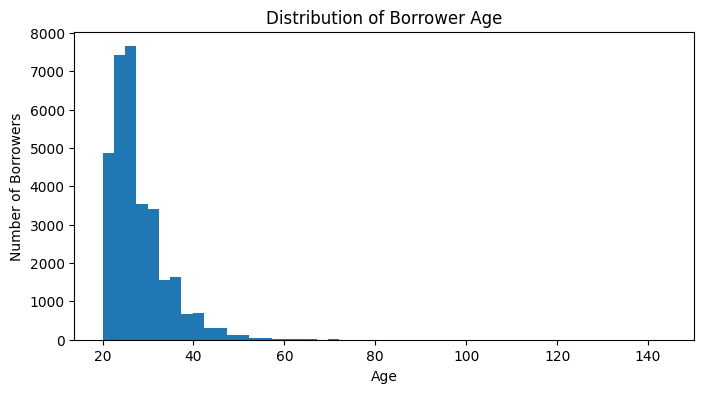

In [13]:
#investigate person_age
df["person_age"].sort_values(ascending=False).head(20)#Xem những age lớn nhất
#Xem full records của nhóm lớn tuổi
age_check = df[df["person_age"] > 80].sort_values(
    "person_age",
    ascending=False
)
age_check
#Đếm
print("Number of observations with age > 80:", len(age_check))
#Xem phân phối age để có context
df["person_age"].describe()
#thêm histogram:
plt.figure(figsize=(8, 4))
plt.hist(df["person_age"], bins=50)
plt.xlabel("Age")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of Borrower Age")
plt.show()


### Age Quality Check

The age distribution contains five clearly implausible observations:

- 3 observations with `person_age = 144`
- 2 observations with `person_age = 123`

Two additional observations aged 84 and 94 are unusual for the lending population but remain plausible and are therefore not treated as data errors.

**Proposed treatment:** Remove the five observations aged 123 and 144 during the cleaning stage. Since these records represent a very small proportion of the dataset and their true ages cannot be reliably inferred, removal is preferred over arbitrary capping or imputation.

No observations are removed at this stage.

In [14]:
#Investigate Employment Length
df["person_emp_length"].sort_values(
    ascending=False
).head(20)#Mục đích:Employment length lớn nhất là bao nhiêu?


210      123.0
0        123.0
32355     41.0
32515     38.0
32428     34.0
31866     31.0
30914     31.0
31867     31.0
32263     31.0
32539     30.0
32562     30.0
32480     29.0
30844     28.0
31203     28.0
32142     28.0
32503     27.0
30776     27.0
31646     27.0
30646     27.0
32379     27.0
Name: person_emp_length, dtype: float64

In [15]:
#xem những observations rất lớn:
emp_check = df[
    df["person_emp_length"] > 60
].sort_values(
    "person_emp_length",
    ascending=False
)

emp_check

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [16]:
print(
    "Number of observations with employment length > 60:",
    len(emp_check)
)

Number of observations with employment length > 60: 2


In [17]:
#Employment Length vs Age
suspicious_emp_age = df[
    df["person_emp_length"] > (df["person_age"] - 14)
][
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_status"
    ]
]

suspicious_emp_age.sort_values(
    "person_emp_length",
    ascending=False
)

,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
210,21,123.0,192000,0


In [18]:
#distribution
df["person_emp_length"].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

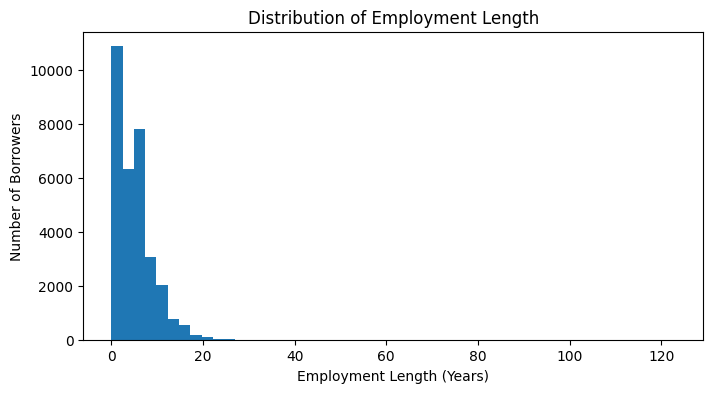

In [19]:
plt.figure(figsize=(8, 4))

plt.hist(
    df["person_emp_length"].dropna(),
    bins=50
)

plt.xlabel("Employment Length (Years)")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of Employment Length")

plt.show()

### Employment Length Quality Check

The employment-length distribution is strongly right-skewed, with a median of 4 years and most observations concentrated at relatively low employment tenures.

Two observations report `person_emp_length = 123` years. These borrowers are aged 22 and 21 respectively, making the reported employment tenure logically impossible.

**Proposed treatment:** Remove these two observations during data cleaning because they are clear data-quality errors and their true employment lengths cannot be reliably inferred.

Other high employment-length observations (e.g., 41, 38, and 34 years) are retained because they remain plausible depending on borrower age.

No observations are removed at this stage.

In [20]:
#Missingness investigation
#Employment length
emp_missing_check = (
    df.assign(
        emp_length_missing=df["person_emp_length"].isna()
    )
    .groupby("emp_length_missing")["loan_status"]
    .agg(["count", "mean"])
)

emp_missing_check["default_rate_pct"] = (
    emp_missing_check["mean"] * 100
)

emp_missing_check

,count,mean,default_rate_pct
emp_length_missing,,,
False,31686,0.215426,21.542637
True,895,0.315084,31.508380


In [21]:
#interest rate
int_rate_missing_check = (
    df.assign(
        int_rate_missing=df["loan_int_rate"].isna()
    )
    .groupby("int_rate_missing")["loan_status"]
    .agg(["count", "mean"])
)

int_rate_missing_check["default_rate_pct"] = (
    int_rate_missing_check["mean"] * 100
)

int_rate_missing_check

,count,mean,default_rate_pct
int_rate_missing,,,
False,29465,0.219379,21.937892
True,3116,0.206675,20.667522


In [22]:
#B18 — Investigate income
#18.1 Summary
df["person_income"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
1%       1.440000e+04
5%       2.288000e+04
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
95%      1.380000e+05
99%      2.252000e+05
max      6.000000e+06
Name: person_income, dtype: float64

In [23]:
#18.2 Top 20 incomes
df.nlargest(
    20,
    "person_income"
)[
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_percent_income",
        "loan_status"
    ]
]

,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,loan_status
32297,144,6000000,12.0,5000,0.00,0
30049,42,2039784,0.0,8450,0.00,0
32546,60,1900000,5.0,1500,0.00,0
32497,63,1782000,13.0,12025,0.01,0
31924,44,1440000,7.0,6400,0.00,0
31922,47,1362000,9.0,6600,0.00,0
17833,32,1200000,1.0,12000,0.01,0
29119,36,1200000,16.0,10000,0.01,0
29120,40,1200000,1.0,10000,0.01,0
17834,34,948000,18.0,2000,0.00,0


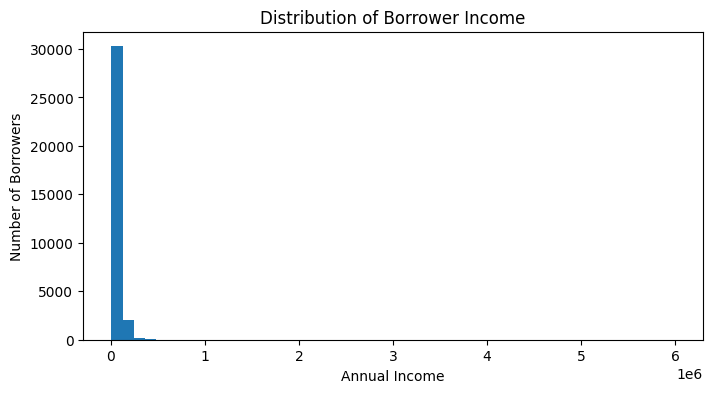

In [24]:
#18.3 Histogram
plt.figure(figsize=(8, 4))

plt.hist(
    df["person_income"],
    bins=50
)

plt.xlabel("Annual Income")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of Borrower Income")

plt.show()

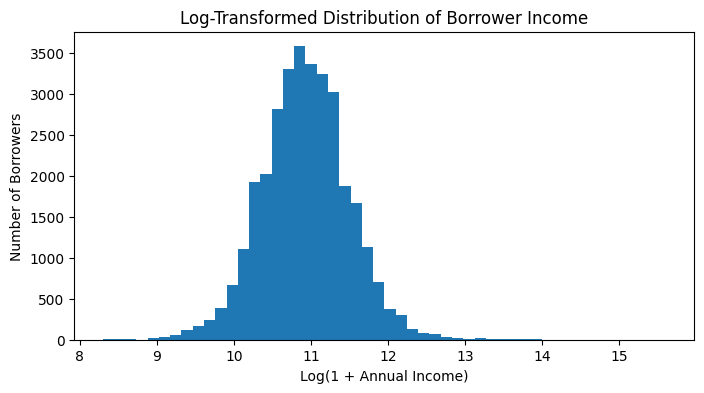

In [25]:
#log scale
plt.figure(figsize=(8, 4))

plt.hist(
    np.log1p(df["person_income"]),
    bins=50
)

plt.xlabel("Log(1 + Annual Income)")
plt.ylabel("Number of Borrowers")
plt.title("Log-Transformed Distribution of Borrower Income")

plt.show()

### Income Distribution Check

`person_income` is strongly right-skewed, with a median of 55,000 and a long upper tail. The 99th percentile is 225,200, while several observations report substantially higher incomes.

These high-income observations are extreme but are not inherently impossible. Therefore, no observations are removed solely based on income magnitude.

The log-transformed distribution was inspected for visualization purposes only. No log transformation has been applied to the modeling data at this stage.

In [26]:
#B19 — Investigate duplicate records kỹ hơn
duplicate_rows = df[
    df.duplicated(keep=False)
].sort_values(
    by=df.columns.tolist()
)

print("Rows involved in duplicate groups:", len(duplicate_rows))
print("Extra duplicate rows:", df.duplicated().sum())

duplicate_rows.head(20)

Rows involved in duplicate groups: 330
Extra duplicate rows: 165


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15944,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
16835,21,8088,RENT,NaN,MEDICAL,C,1200,15.23,0,0.15,Y,2
2431,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
17758,21,15600,RENT,0.0,MEDICAL,A,2800,7.40,1,0.18,N,4
2498,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
17601,21,18000,RENT,0.0,DEBTCONSOLIDATION,A,3000,7.90,1,0.17,N,2
1778,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3
17642,21,20000,RENT,0.0,MEDICAL,A,2000,NaN,0,0.10,N,3
740,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3
17283,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3


### Duplicate Record Check

A total of 330 rows are involved in exact duplicate groups, corresponding to 165 additional duplicate records.

Because the dataset does not contain a unique borrower or application identifier, these records cannot be definitively identified as duplicate customers. However, the duplicated rows are identical across all available variables.

**Proposed treatment:** Keep the first occurrence and remove the 165 additional exact duplicate records to avoid unintentionally overweighting identical observations during model development.

## Data Quality Decisions

Before preprocessing, the following data-quality decisions were established:

| Issue | Finding | Decision |
|---|---|---|
| Implausible age | 3 records aged 144 and 2 aged 123 | Remove |
| High but plausible age | Ages 84 and 94 | Retain |
| Invalid employment length | 2 records report 123 years of employment at ages 22 and 21 | Remove |
| Missing employment length | 895 records; missing group shows a higher observed default rate | Preserve missingness for later WoE/preprocessing treatment |
| Missing interest rate | 3,116 records; relatively small difference in observed default rate | Retain for later preprocessing |
| Exact duplicate records | 165 additional exact duplicate rows | Remove additional copies |
| High income observations | Strong right tail, but values are not inherently impossible | Retain |
| Rare categorical levels | `OTHER` home ownership contains relatively few observations | Retain for WoE/binning analysis |

Cleaning is limited to clearly identified data-quality problems. Statistical outliers are not removed solely because they are extreme.

In [27]:
#B21-clean
df_clean = df.copy()

In [28]:
#B21.1 — Remove exact duplicates
df_clean = df_clean.drop_duplicates()
print("Rows after duplicate removal:", len(df_clean))

Rows after duplicate removal: 32416


In [29]:
#B21.2 — Remove clearly implausible ages
df_clean = df_clean[
    ~df_clean["person_age"].isin([123, 144])
].copy()
print(
    "Remaining age 123/144:",
    df_clean["person_age"].isin([123, 144]).sum()
)

Remaining age 123/144: 0


In [30]:
#B21.3 — Remove invalid employment length
df_clean = df_clean[
    df_clean["person_emp_length"].isna()
    |
    (df_clean["person_emp_length"] != 123)
].copy()
print(
    "Remaining employment length = 123:",
    (df_clean["person_emp_length"] == 123).sum()
)

Remaining employment length = 123: 0


In [31]:
#B22 — Cleaning audit
print("Raw dataset rows:", len(df))
print("Clean dataset rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print(
    "Percentage removed:",
    f"{(len(df) - len(df_clean)) / len(df) * 100:.2f}%"
)

Raw dataset rows: 32581
Clean dataset rows: 32409
Rows removed: 172
Percentage removed: 0.53%


In [32]:
#B23 — Verify cleaning
print(
    "Exact duplicates:",
    df_clean.duplicated().sum()
)

print(
    "Age 123/144:",
    df_clean["person_age"].isin([123, 144]).sum()
)

print(
    "Employment length 123:",
    (df_clean["person_emp_length"] == 123).sum()
)
df_clean.describe().T

Exact duplicates: 0
Age 123/144: 0
Employment length 123: 0


,count,mean,std,min,25%,50%,75%,max
person_age,32409.0,27.730754,6.210445,20.00,23.00,26.00,30.00,94.00
person_income,32409.0,65894.277053,52517.869973,4000.00,38500.00,55000.00,79200.00,2039784.00
person_emp_length,31522.0,4.782850,4.037343,0.00,2.00,4.00,7.00,41.00
loan_amnt,32409.0,9592.486655,6320.885127,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,29315.0,11.017099,3.241718,5.42,7.90,10.99,13.47,23.22
loan_status,32409.0,0.218705,0.413374,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32409.0,0.170248,0.106785,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32409.0,5.811194,4.057899,2.00,3.00,4.00,8.00,30.00


## Data Cleaning Summary

The raw dataset contained 32,581 observations.

Data cleaning removed:

- 165 additional exact duplicate records.
- 5 observations with clearly implausible ages of 123 or 144 years.
- 2 observations with logically impossible employment lengths of 123 years.

The cleaned dataset contains **32,409 observations**, representing a total removal of **172 records (0.53%)**.

After cleaning:

- No exact duplicate records remain.
- The maximum borrower age is 94 years.
- The maximum employment length is 41 years.
- Missing values in `person_emp_length` and `loan_int_rate` are intentionally retained for later preprocessing and WoE/binning analysis.

Extreme observations were not removed solely because of statistical magnitude; removal was limited to clearly identified data-quality issues.

In [33]:
#PHASE 2 — RISK EDA
#B24 — Default rate sau cleaning
clean_default_rate = df_clean["loan_status"].mean()

print("Clean dataset rows:", len(df_clean))
print(f"Observed default rate: {clean_default_rate:.2%}")

Clean dataset rows: 32409
Observed default rate: 21.87%


In [34]:
target_summary = (
    df_clean["loan_status"]
    .value_counts()
    .sort_index()
    .rename_axis("loan_status")
    .reset_index(name="count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(df_clean) * 100
)

target_summary

,loan_status,count,percentage
0,0,25321,78.129532
1,1,7088,21.870468


In [35]:
def default_rate_by_group(data, column):
    result = (
        data
        .groupby(
            column,
            dropna=False,
            observed=True
        )["loan_status"]
        .agg(
            n_borrowers="count",
            n_defaults="sum",
            default_rate="mean"
        )
        .reset_index()
    )

    result["default_rate_pct"] = (
        result["default_rate"] * 100
    )

    return result

In [36]:
#B26 — Previous default history
previous_default_eda = default_rate_by_group(
    df_clean,
    "cb_person_default_on_file"
)

previous_default_eda

,cb_person_default_on_file,n_borrowers,n_defaults,default_rate,default_rate_pct
0,N,26680,4919,0.18437,18.437031
1,Y,5729,2169,0.37860,37.860010


In [37]:
#B27 — Home ownership
home_eda = default_rate_by_group(
    df_clean,
    "person_home_ownership"
).sort_values(
    "default_rate",
    ascending=False
)

home_eda

,person_home_ownership,n_borrowers,n_defaults,default_rate,default_rate_pct
3,RENT,16374,5176,0.316111,31.611091
1,OTHER,106,33,0.311321,31.132075
0,MORTGAGE,13366,1687,0.126216,12.621577
2,OWN,2563,192,0.074912,7.491221


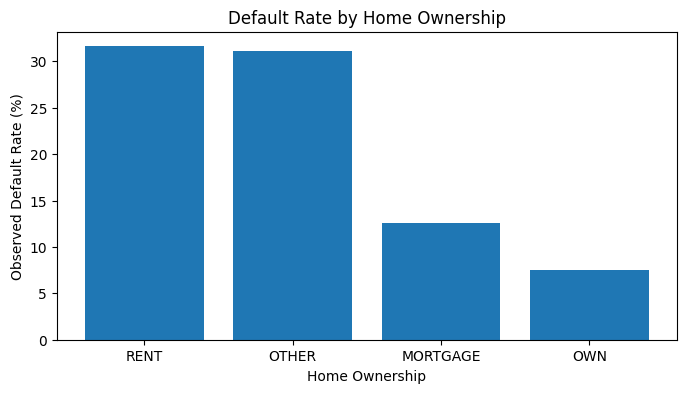

In [38]:
plt.figure(figsize=(8, 4))

plt.bar(
    home_eda["person_home_ownership"],
    home_eda["default_rate_pct"]
)

plt.xlabel("Home Ownership")
plt.ylabel("Observed Default Rate (%)")
plt.title("Default Rate by Home Ownership")

plt.show()

In [39]:
#B28 — Loan intent
intent_eda = default_rate_by_group(
    df_clean,
    "loan_intent"
).sort_values(
    "default_rate",
    ascending=False
)

intent_eda


,loan_intent,n_borrowers,n_defaults,default_rate,default_rate_pct
0,DEBTCONSOLIDATION,5189,1488,0.286760,28.676045
3,MEDICAL,6042,1617,0.267627,26.762661
2,HOMEIMPROVEMENT,3594,940,0.261547,26.154702
4,PERSONAL,5496,1093,0.198872,19.887191
1,EDUCATION,6409,1106,0.172570,17.256982
5,VENTURE,5679,844,0.148618,14.861771


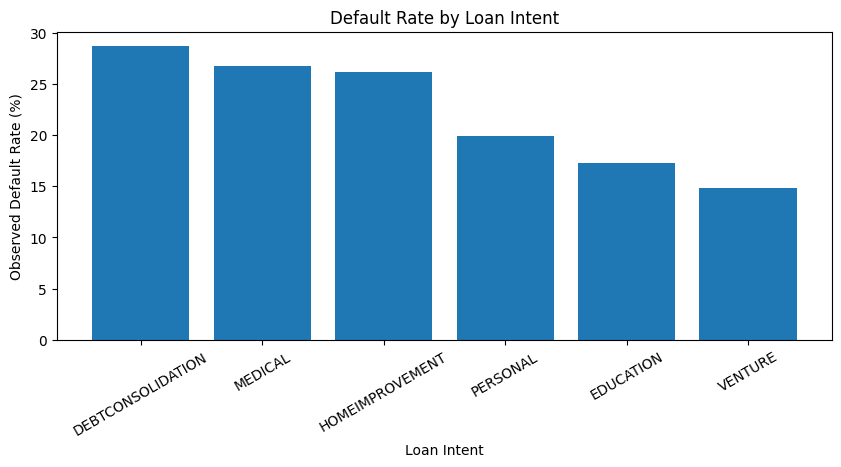

In [40]:
plt.figure(figsize=(10, 4))

plt.bar(
    intent_eda["loan_intent"],
    intent_eda["default_rate_pct"]
)

plt.xlabel("Loan Intent")
plt.ylabel("Observed Default Rate (%)")
plt.title("Default Rate by Loan Intent")

plt.xticks(rotation=30)

plt.show()

In [41]:
#B29 — Loan Grade
grade_eda = default_rate_by_group(
    df_clean,
    "loan_grade"
).sort_values(
    "loan_grade"
)

grade_eda

,loan_grade,n_borrowers,n_defaults,default_rate,default_rate_pct
0,A,10702,1066,0.099608,9.960755
1,B,10384,1695,0.163232,16.323190
2,C,6436,1336,0.207582,20.758235
3,D,3619,2137,0.590495,59.049461
4,E,963,621,0.644860,64.485981
5,F,241,170,0.705394,70.539419
6,G,64,63,0.984375,98.437500


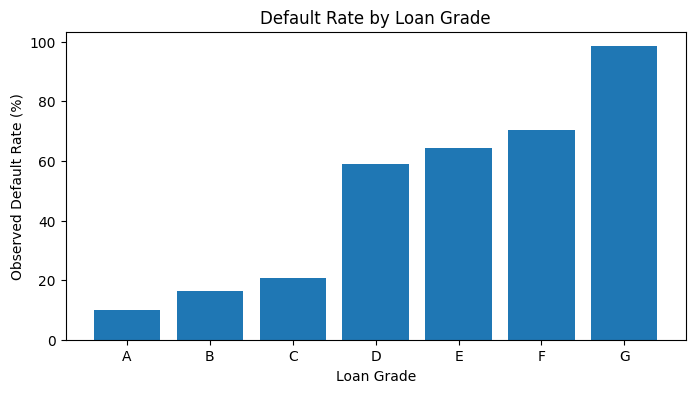

In [42]:
plt.figure(figsize=(8, 4))

plt.bar(
    grade_eda["loan_grade"],
    grade_eda["default_rate_pct"]
)

plt.xlabel("Loan Grade")
plt.ylabel("Observed Default Rate (%)")
plt.title("Default Rate by Loan Grade")

plt.show()

**Modeling note:** `loan_grade` may contain information from an existing credit assessment process. Its availability and construction are not documented sufficiently in the dataset to determine whether it should be used as an application-time predictor. Therefore, its inclusion in the final PD model will be treated cautiously and evaluated separately.

In [43]:
#B30 — loan_percent_income
df_eda = df_clean.copy()

df_eda["loan_income_band"] = pd.cut(
    df_eda["loan_percent_income"],
    bins=[-np.inf, 0.10, 0.20, 0.30, 0.40, np.inf],
    labels=[
        "<10%",
        "10–20%",
        "20–30%",
        "30–40%",
        ">40%"
    ]
)
lti_eda = default_rate_by_group(
    df_eda,
    "loan_income_band"
)

lti_eda

,loan_income_band,n_borrowers,n_defaults,default_rate,default_rate_pct
0,<10%,10426,1226,0.117591,11.759064
1,10–20%,11999,1815,0.151263,15.126261
2,20–30%,6166,1358,0.220240,22.024003
3,30–40%,2700,1860,0.688889,68.888889
4,>40%,1118,829,0.741503,74.150268


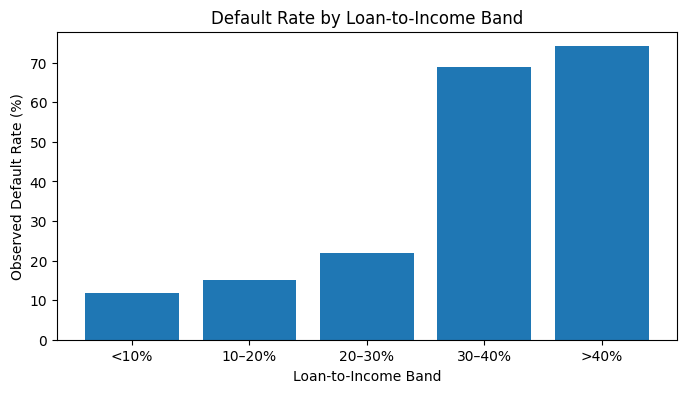

In [44]:
plt.figure(figsize=(8, 4))

plt.bar(
    lti_eda["loan_income_band"].astype(str),
    lti_eda["default_rate_pct"]
)

plt.xlabel("Loan-to-Income Band")
plt.ylabel("Observed Default Rate (%)")
plt.title("Default Rate by Loan-to-Income Band")

plt.show()

In [45]:
#B31 — Income bands
df_eda["income_quintile"] = pd.qcut(
    df_eda["person_income"],
    q=5,
    duplicates="drop"
)
income_eda = default_rate_by_group(
    df_eda,
    "income_quintile"
)

income_eda

,income_quintile,n_borrowers,n_defaults,default_rate,default_rate_pct
0,"(3999.999, 35000.0]",6591,2855,0.433166,43.316644
1,"(35000.0, 49000.0]",6508,1532,0.235403,23.540258
2,"(49000.0, 63000.0]",6366,1162,0.182532,18.253220
3,"(63000.0, 86000.0]",6484,947,0.146052,14.605182
4,"(86000.0, 2039784.0]",6460,592,0.091641,9.164087


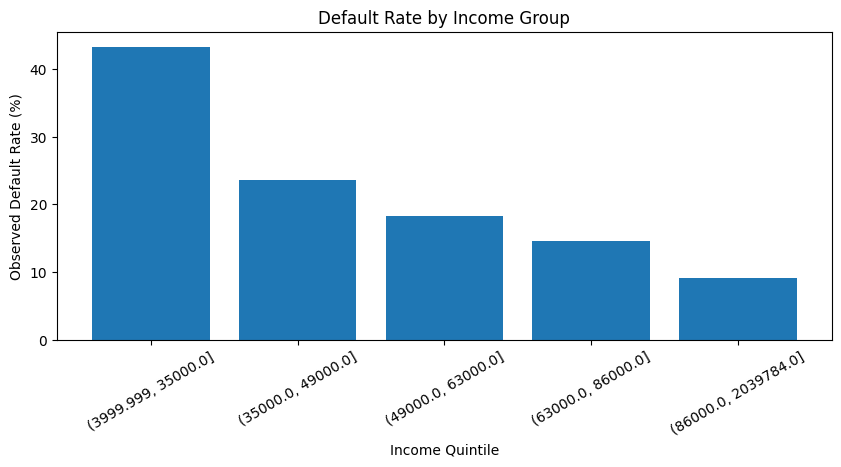

In [46]:
plt.figure(figsize=(10, 4))

plt.bar(
    income_eda["income_quintile"].astype(str),
    income_eda["default_rate_pct"]
)

plt.xlabel("Income Quintile")
plt.ylabel("Observed Default Rate (%)")
plt.title("Default Rate by Income Group")

plt.xticks(rotation=30)

plt.show()

In [47]:
#B32 — Interest Rate
df_eda["interest_rate_band"] = pd.cut(
    df_eda["loan_int_rate"],
    bins=[-np.inf, 8, 10, 12, 15, np.inf],
    labels=[
        "<8%",
        "8–10%",
        "10–12%",
        "12–15%",
        ">15%"
    ]
)
rate_eda = default_rate_by_group(
    df_eda,
    "interest_rate_band"
)

rate_eda

,interest_rate_band,n_borrowers,n_defaults,default_rate,default_rate_pct
0,<8%,7905,737,0.093232,9.323213
1,8–10%,3715,531,0.142934,14.293405
2,10–12%,6582,1102,0.167426,16.742631
3,12–15%,7681,2084,0.271319,27.131884
4,>15%,3432,1993,0.580711,58.071096
5,NaN,3094,641,0.207175,20.717518


### Previous Default History

Borrowers with a previous default on file show a substantially higher observed default rate (37.86%) than borrowers without a previous default record (18.44%).

This suggests that prior default history contains useful discriminatory information for separating higher- and lower-risk borrowers in this sample.

### Home Ownership

Observed default rates differ substantially across home-ownership categories. RENT borrowers show a default rate of 31.61%, compared with 12.62% for MORTGAGE and 7.49% for OWN borrowers.

The OTHER category also shows a high observed default rate (31.13%), but it contains only 106 observations and should therefore be interpreted cautiously. Rare-category treatment will be reconsidered during WoE binning.

### Loan Intent

Observed default rates vary by loan purpose. DEBTCONSOLIDATION has the highest observed default rate at 28.68%, followed by MEDICAL and HOMEIMPROVEMENT, while VENTURE has the lowest rate at 14.86%.

These results indicate that loan purpose may contain discriminatory information, although the strength of the relationship will be assessed formally using Information Value.

## Risk EDA Summary

The cleaned development sample contains 32,409 observations with an overall observed default rate of 21.87%.

Several variables show clear separation in observed default risk:

- Borrowers with a previous default on file have a substantially higher observed default rate than borrowers without prior default history.
- RENT borrowers show higher observed default rates than MORTGAGE and OWN borrowers.
- Default rates vary across loan purposes, with DEBTCONSOLIDATION showing the highest observed rate in the current sample.
- Loan-to-income shows a strong monotonic relationship with observed default risk, particularly above the 30% level.
- Income shows an inverse monotonic relationship with observed default risk.
- Interest rate shows a strong positive relationship with observed default risk.
- Loan grade shows exceptionally strong monotonic separation from grade A through G.

These results represent associations within the sample and should not be interpreted as causal relationships.

`loan_grade` and `loan_int_rate` require additional modeling caution because they may partially reflect an existing underwriting or pricing process. Their availability and construction are not fully documented in the dataset.

The exploratory bins used in this section are for descriptive analysis only. Final binning, WoE estimation, and variable selection will be performed using the training sample only.

In [48]:
#PHASE 3 — Split trước khi WoE
#B34 — Train/Test Split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df_clean,
    test_size=0.20,
    random_state=42,
    stratify=df_clean["loan_status"]
)

In [49]:
#B35 — Verify split
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "Train default rate:",
    f"{train_df['loan_status'].mean():.2%}"
)

print(
    "Test default rate:",
    f"{test_df['loan_status'].mean():.2%}"
)

Train rows: 25927
Test rows: 6482
Train default rate: 21.87%
Test default rate: 21.88%


In [50]:
print(
    "Overlap in index:",
    len(set(train_df.index) & set(test_df.index))
)

Overlap in index: 0


In [51]:
#PHASE 4 — WoE & IV
#B37 — Tạo bins trên TRAIN ONLY
train_woe_demo = train_df.copy()
train_woe_demo["lti_bin"] = pd.cut(
    train_woe_demo["loan_percent_income"],
    bins=[-np.inf, 0.10, 0.20, 0.30, 0.40, np.inf],
    labels=[
        "<10%",
        "10-20%",
        "20-30%",
        "30-40%",
        ">40%"
    ]
)

In [52]:
#B38 — Đếm Good và Bad trong mỗi bin
lti_woe = (
    train_woe_demo
    .groupby("lti_bin", observed=True)["loan_status"]
    .agg(
        total="count",
        bad="sum"
    )
    .reset_index()
)

lti_woe["good"] = (
    lti_woe["total"] - lti_woe["bad"]
)

lti_woe

,lti_bin,total,bad,good
0,<10%,8336,978,7358
1,10-20%,9595,1457,8138
2,20-30%,4945,1086,3859
3,30-40%,2145,1476,669
4,>40%,906,673,233


In [53]:
#B39 — Từ count sang distribution
total_good = lti_woe["good"].sum()
total_bad = lti_woe["bad"].sum()

lti_woe["dist_good"] = (
    lti_woe["good"] / total_good
)

lti_woe["dist_bad"] = (
    lti_woe["bad"] / total_bad
)

lti_woe

,lti_bin,total,bad,good,dist_good,dist_bad
0,<10%,8336,978,7358,0.363232,0.172487
1,10-20%,9595,1457,8138,0.401738,0.256966
2,20-30%,4945,1086,3859,0.190502,0.191534
3,30-40%,2145,1476,669,0.033026,0.260317
4,>40%,906,673,233,0.011502,0.118695


In [54]:
#B40 — Đây mới là Weight of Evidence
lti_woe["woe"] = np.log(
    lti_woe["dist_good"]
    /
    lti_woe["dist_bad"]
)

In [55]:
#B41 — Information Value
lti_woe["iv_component"] = (
    (lti_woe["dist_good"] - lti_woe["dist_bad"])
    *
    lti_woe["woe"]
)

lti_iv = lti_woe["iv_component"].sum()

print(lti_woe)
print()
print("Information Value:", lti_iv)

  lti_bin  total   bad  good  dist_good  dist_bad       woe  iv_component
0    <10%   8336   978  7358   0.363232  0.172487  0.744722      0.142053
1  10-20%   9595  1457  8138   0.401738  0.256966  0.446854      0.064692
2  20-30%   4945  1086  3859   0.190502  0.191534 -0.005404      0.000006
3  30-40%   2145  1476   669   0.033026  0.260317 -2.064618      0.469271
4    >40%    906   673   233   0.011502  0.118695 -2.334018      0.250190

Information Value: 0.9262102689317933


### WoE / IV Demonstration — Loan-to-Income

`loan_percent_income` shows a strong and approximately monotonic WoE pattern in the training sample. Lower loan-to-income bins are concentrated more heavily among non-default observations, while higher loan-to-income bins are concentrated more heavily among default observations.

Using the convention:

WoE = ln(Distribution of Good / Distribution of Bad)

the WoE decreases from approximately +0.745 for the lowest LTI bin to -2.334 for the highest LTI bin.

The resulting Information Value is approximately 0.93 under this demonstration binning, indicating very strong separation between good and bad observations in the training sample.

The current cutoffs are used to demonstrate the WoE/IV calculation and are not treated as final production/model-development bins. Final binning decisions will be derived using the training sample only and evaluated for sample size, stability, interpretability, and potential information leakage.

In [56]:
#B42 — thêm default rate vào bảng WoE
lti_woe["default_rate"] = (
    lti_woe["bad"] / lti_woe["total"]
)

lti_woe["default_rate_pct"] = (
    lti_woe["default_rate"] * 100
)

lti_woe[
    [
        "lti_bin",
        "total",
        "good",
        "bad",
        "default_rate_pct",
        "dist_good",
        "dist_bad",
        "woe",
        "iv_component"
    ]
]

,lti_bin,total,good,bad,default_rate_pct,dist_good,dist_bad,woe,iv_component
0,<10%,8336,7358,978,11.732246,0.363232,0.172487,0.744722,0.142053
1,10-20%,9595,8138,1457,15.184992,0.401738,0.256966,0.446854,0.064692
2,20-30%,4945,3859,1086,21.961577,0.190502,0.191534,-0.005404,0.000006
3,30-40%,2145,669,1476,68.811189,0.033026,0.260317,-2.064618,0.469271
4,>40%,906,233,673,74.282561,0.011502,0.118695,-2.334018,0.250190


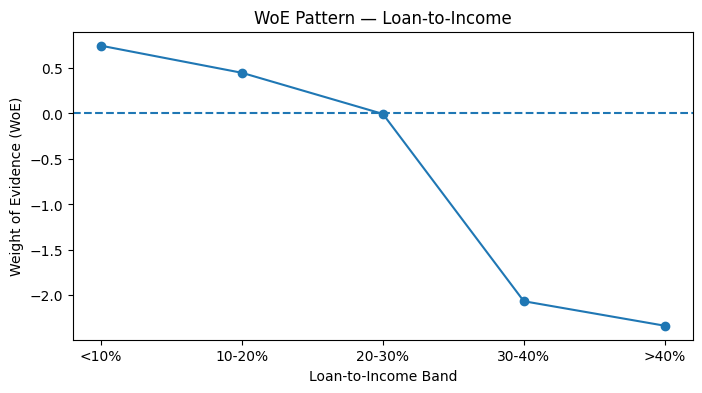

In [57]:
#B43 — plot WoE
plt.figure(figsize=(8, 4))

plt.plot(
    lti_woe["lti_bin"].astype(str),
    lti_woe["woe"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Loan-to-Income Band")
plt.ylabel("Weight of Evidence (WoE)")
plt.title("WoE Pattern — Loan-to-Income")

plt.show()

In [58]:
#B44 — Trước khi bin tất cả variables, inventory feature
print(train_df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [59]:
feature_summary = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "n_unique": train_df.nunique(dropna=False),
    "missing_n": train_df.isna().sum(),
    "missing_pct": train_df.isna().mean() * 100
})

feature_summary

,dtype,n_unique,missing_n,missing_pct
person_age,int64,52,0,0.000000
person_income,int64,3703,0,0.000000
person_home_ownership,object,4,0,0.000000
person_emp_length,float64,34,710,2.738458
loan_intent,object,6,0,0.000000
loan_grade,object,7,0,0.000000
loan_amnt,int64,729,0,0.000000
loan_int_rate,float64,344,2463,9.499749
loan_status,int64,2,0,0.000000
loan_percent_income,float64,77,0,0.000000


In [60]:
#PHASE 4B — WoE/IV cho toàn bộ variables
# B45 — Define feature groups

target = "loan_status"

numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "cb_person_default_on_file"
]

caution_features = [
    "loan_grade"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Caution features:", caution_features)

Numeric features: 7
Categorical features: 3
Caution features: ['loan_grade']


In [61]:
#B47 — Viết function WoE/IV cho một biến numeric
# B47 — WoE / IV function for numeric variables

def woe_iv_numeric(data, feature, target="loan_status", q=5):

    temp = data[[feature, target]].copy()

    # Separate missing observations
    missing_mask = temp[feature].isna()

    non_missing = temp.loc[~missing_mask].copy()
    missing = temp.loc[missing_mask].copy()

    # Quantile binning learned from this data (TRAIN only)
    non_missing["bin"] = pd.qcut(
        non_missing[feature],
        q=q,
        duplicates="drop"
    )

    # Convert bins to string so MISSING can be added
    non_missing["bin"] = non_missing["bin"].astype(str)

    if len(missing) > 0:
        missing["bin"] = "MISSING"
        binned = pd.concat(
            [non_missing, missing],
            ignore_index=True
        )
    else:
        binned = non_missing

    # Good / Bad counts
    table = (
        binned
        .groupby("bin", observed=True)[target]
        .agg(
            total="count",
            bad="sum"
        )
        .reset_index()
    )

    table["good"] = (
        table["total"] - table["bad"]
    )

    # Overall Good / Bad
    total_good = table["good"].sum()
    total_bad = table["bad"].sum()

    # Distribution
    table["dist_good"] = (
        table["good"] / total_good
    )

    table["dist_bad"] = (
        table["bad"] / total_bad
    )

    # Avoid log(0)
    eps = 1e-6

    table["woe"] = np.log(
        (table["dist_good"] + eps)
        /
        (table["dist_bad"] + eps)
    )

    # IV contribution
    table["iv_component"] = (
        (table["dist_good"] - table["dist_bad"])
        *
        table["woe"]
    )

    table["default_rate_pct"] = (
        table["bad"] / table["total"] * 100
    )

    iv = table["iv_component"].sum()

    return table, iv

In [62]:
#B49 — Test function với person_income
# B49 — Test numeric WoE function

income_woe, income_iv = woe_iv_numeric(
    train_df,
    "person_income",
    q=5
)

print(income_woe)
print()
print("person_income IV:", income_iv)

                    bin  total   bad  good  dist_good  dist_bad       woe  \
0    (35000.0, 48996.0]   5149  1193  3956   0.195291  0.210406 -0.074549   
1   (4079.999, 35000.0]   5244  2281  2963   0.146270  0.402293 -1.011719   
2    (48996.0, 63000.0]   5215   991  4224   0.208521  0.174780  0.176511   
3    (63000.0, 86000.0]   5191   730  4461   0.220220  0.128748  0.536769   
4  (86000.0, 2039784.0]   5128   475  4653   0.229698  0.083774  1.008634   

   iv_component  default_rate_pct  
0      0.001127         23.169547  
1      0.259023         43.497330  
2      0.005956         19.002876  
3      0.049100         14.062801  
4      0.147184          9.262871  

person_income IV: 0.4623885919209434


In [63]:
#B50 — Test person_emp_length để kiểm tra MISSING
# B50 — Employment length WoE

emp_woe, emp_iv = woe_iv_numeric(
    train_df,
    "person_emp_length",
    q=5
)

print(emp_woe)
print()
print("person_emp_length IV:", emp_iv)

             bin  total   bad  good  dist_good  dist_bad       woe  \
0  (-0.001, 1.0]   5572  1532  4040   0.199437  0.270194 -0.303639   
1     (1.0, 3.0]   5826  1355  4471   0.220714  0.238977 -0.079500   
2     (3.0, 5.0]   4612   918  3694   0.182357  0.161905  0.118956   
3     (5.0, 8.0]   5230   962  4268   0.210693  0.169665  0.216574   
4    (8.0, 38.0]   3977   669  3308   0.163302  0.117989  0.325001   
5        MISSING    710   234   476   0.023498  0.041270 -0.563196   

   iv_component  default_rate_pct  
0      0.021485         27.494616  
1      0.001452         23.257810  
2      0.002433         19.904597  
3      0.008886         18.393881  
4      0.014727         16.821725  
5      0.010009         32.957746  

person_emp_length IV: 0.05899039169111756


In [64]:
#B51 — Test loan_int_rate
# B51 — Interest rate WoE

rate_woe, rate_iv = woe_iv_numeric(
    train_df,
    "loan_int_rate",
    q=5
)

print(rate_woe)
print()
print("loan_int_rate IV:", rate_iv)

              bin  total   bad  good  dist_good  dist_bad       woe  \
0  (10.25, 11.86]   4565   779  3786   0.186898  0.137390  0.307741   
1  (11.86, 13.98]   4773   979  3794   0.187293  0.172663  0.081333   
2  (13.98, 23.22]   4597  2349  2248   0.110974  0.414286 -1.317253   
3   (5.419, 7.51]   4710   413  4297   0.212124  0.072840  1.068904   
4   (7.51, 10.25]   4819   641  4178   0.206250  0.113051  0.601243   
5         MISSING   2463   509  1954   0.096460  0.089771  0.071874   

   iv_component  default_rate_pct  
0      0.015236         17.064622  
1      0.001190         20.511209  
2      0.399538         51.098543  
3      0.148882          8.768577  
4      0.056035         13.301515  
5      0.000481         20.665855  

loan_int_rate IV: 0.6213620103617556


In [65]:
# B52 — IV summary for numeric features

numeric_iv_results = []
numeric_woe_tables = {}

for feature in numeric_features:

    table, iv = woe_iv_numeric(
        train_df,
        feature,
        q=5
    )

    numeric_woe_tables[feature] = table

    numeric_iv_results.append({
        "feature": feature,
        "iv": iv
    })

numeric_iv_summary = (
    pd.DataFrame(numeric_iv_results)
    .sort_values(
        "iv",
        ascending=False
    )
    .reset_index(drop=True)
)

numeric_iv_summary

,feature,iv
0,loan_percent_income,0.708438
1,loan_int_rate,0.621362
2,person_income,0.462389
3,loan_amnt,0.076526
4,person_emp_length,0.058990
5,person_age,0.007667
6,cb_person_cred_hist_length,0.004364


In [66]:
#B53 — Categorical WoE/IV
# B53 — WoE / IV function for categorical variables

def woe_iv_categorical(data, feature, target="loan_status"):

    temp = data[[feature, target]].copy()

    temp[feature] = (
        temp[feature]
        .fillna("MISSING")
        .astype(str)
    )

    table = (
        temp
        .groupby(feature, observed=True)[target]
        .agg(
            total="count",
            bad="sum"
        )
        .reset_index()
    )

    table["good"] = (
        table["total"] - table["bad"]
    )

    total_good = table["good"].sum()
    total_bad = table["bad"].sum()

    table["dist_good"] = (
        table["good"] / total_good
    )

    table["dist_bad"] = (
        table["bad"] / total_bad
    )

    eps = 1e-6

    table["woe"] = np.log(
        (table["dist_good"] + eps)
        /
        (table["dist_bad"] + eps)
    )

    table["iv_component"] = (
        (table["dist_good"] - table["dist_bad"])
        *
        table["woe"]
    )

    table["default_rate_pct"] = (
        table["bad"] / table["total"] * 100
    )

    iv = table["iv_component"].sum()

    return table, iv

In [67]:
#B54 — Test với home ownership
home_woe, home_iv = woe_iv_categorical(
    train_df,
    "person_home_ownership"
)

print(home_woe)
print()
print("person_home_ownership IV:", home_iv)

  person_home_ownership  total   bad  good  dist_good  dist_bad       woe  \
0              MORTGAGE  10715  1344  9371   0.462606  0.237037  0.668656   
1                 OTHER     83    28    55   0.002715  0.004938 -0.598017   
2                   OWN   2030   150  1880   0.092807  0.026455  1.255053   
3                  RENT  13099  4148  8951   0.441872  0.731570 -0.504171   

   iv_component  default_rate_pct  
0      0.150828         12.543164  
1      0.001329         33.734940  
2      0.083276          7.389163  
3      0.146057         31.666539  

person_home_ownership IV: 0.38149037570224387


In [68]:
#B55 — Categorical IV summary
categorical_iv_results = []
categorical_woe_tables = {}

for feature in categorical_features:

    table, iv = woe_iv_categorical(
        train_df,
        feature
    )

    categorical_woe_tables[feature] = table

    categorical_iv_results.append({
        "feature": feature,
        "iv": iv
    })

categorical_iv_summary = (
    pd.DataFrame(categorical_iv_results)
    .sort_values(
        "iv",
        ascending=False
    )
    .reset_index(drop=True)
)

categorical_iv_summary

,feature,iv
0,person_home_ownership,0.381490
1,cb_person_default_on_file,0.148590
2,loan_intent,0.090643


In [69]:
#B56 — Loan grade riêng
grade_woe, grade_iv = woe_iv_categorical(
    train_df,
    "loan_grade"
)

print(grade_woe)
print()
print("loan_grade IV:", grade_iv)

  loan_grade  total   bad  good  dist_good  dist_bad       woe  iv_component  \
0          A   8530   855  7675   0.378881  0.150794  0.921307      0.210139   
1          B   8281  1362  6919   0.341561  0.240212  0.352005      0.035675   
2          C   5221  1061  4160   0.205361  0.187125  0.092991      0.001696   
3          D   2890  1707  1183   0.058400  0.301058 -1.639981      0.397956   
4          E    755   494   261   0.012884  0.087125 -1.911260      0.141893   
5          F    196   138    58   0.002863  0.024339 -2.139814      0.045953   
6          G     54    53     1   0.000049  0.009347 -5.223656      0.048570   

   default_rate_pct  
0         10.023447  
1         16.447289  
2         20.321777  
3         59.065744  
4         65.430464  
5         70.408163  
6         98.148148  

loan_grade IV: 0.8818824149607312


In [70]:
# B57 — Initial feature screening decisions

feature_decisions = pd.DataFrame([
    ["loan_percent_income", 0.708438, "Strong", "Derived from loan amount and income", "KEEP / REVIEW REDUNDANCY"],
    ["loan_int_rate", 0.621362, "Strong", "Potential pricing / underwriting information", "CAUTION"],
    ["person_income", 0.462389, "Strong", "Related to loan_percent_income", "KEEP / REVIEW REDUNDANCY"],
    ["person_home_ownership", 0.381490, "Strong", "Rare OTHER category", "KEEP"],
    ["cb_person_default_on_file", 0.148590, "Moderate", "Prior credit history signal", "KEEP"],
    ["loan_intent", 0.090643, "Moderate", "Business-interpretable categorical variable", "KEEP"],
    ["loan_amnt", 0.076526, "Moderate", "Related to loan_percent_income", "REVIEW"],
    ["person_emp_length", 0.058990, "Moderate", "Missingness carries risk information", "KEEP"],
    ["person_age", 0.007667, "Weak", "Low standalone discrimination", "REVIEW / DROP"],
    ["cb_person_cred_hist_length", 0.004364, "Weak", "Low standalone discrimination", "REVIEW / DROP"],
    ["loan_grade", 0.881882, "Very strong", "Potential existing underwriting information", "SENSITIVITY ONLY"]
], columns=[
    "feature",
    "iv",
    "signal",
    "concern",
    "initial_decision"
])

feature_decisions

,feature,iv,signal,concern,initial_decision
0,loan_percent_income,0.708438,Strong,Derived from loan amount and income,KEEP / REVIEW REDUNDANCY
1,loan_int_rate,0.621362,Strong,Potential pricing / underwriting information,CAUTION
2,person_income,0.462389,Strong,Related to loan_percent_income,KEEP / REVIEW REDUNDANCY
3,person_home_ownership,0.381490,Strong,Rare OTHER category,KEEP
4,cb_person_default_on_file,0.148590,Moderate,Prior credit history signal,KEEP
5,loan_intent,0.090643,Moderate,Business-interpretable categorical variable,KEEP
6,loan_amnt,0.076526,Moderate,Related to loan_percent_income,REVIEW
7,person_emp_length,0.058990,Moderate,Missingness carries risk information,KEEP
8,person_age,0.007667,Weak,Low standalone discrimination,REVIEW / DROP
9,cb_person_cred_hist_length,0.004364,Weak,Low standalone discrimination,REVIEW / DROP


In [71]:
#B58 — kiểm tra redundancy
# B58 — Check relationship among related numeric features

related_features = [
    "person_income",
    "loan_amnt",
    "loan_percent_income",
    "loan_int_rate"
]

train_df[related_features].corr(method="spearman")

,person_income,loan_amnt,loan_percent_income,loan_int_rate
person_income,1.000000,0.405099,-0.364716,-0.036865
loan_amnt,0.405099,1.000000,0.656415,0.105380
loan_percent_income,-0.364716,0.656415,1.000000,0.125839
loan_int_rate,-0.036865,0.105380,0.125839,1.000000


In [72]:
#B59 — kiểm tra grade và interest rate
# B59 — Relationship between loan grade and interest rate

grade_rate_summary = (
    train_df
    .groupby("loan_grade", observed=True)
    .agg(
        n_borrowers=("loan_status", "size"),
        avg_interest_rate=("loan_int_rate", "mean"),
        median_interest_rate=("loan_int_rate", "median"),
        default_rate=("loan_status", "mean")
    )
    .reset_index()
)

grade_rate_summary["default_rate_pct"] = (
    grade_rate_summary["default_rate"] * 100
)

grade_rate_summary

,loan_grade,n_borrowers,avg_interest_rate,median_interest_rate,default_rate,default_rate_pct
0,A,8530,7.337264,7.49,0.100234,10.023447
1,B,8281,10.987116,10.99,0.164473,16.447289
2,C,5221,13.471160,13.49,0.203218,20.321777
3,D,2890,15.368891,15.31,0.590657,59.065744
4,E,755,17.008782,16.77,0.654305,65.430464
5,F,196,18.617701,18.53,0.704082,70.408163
6,G,54,20.273529,20.16,0.981481,98.148148


In [73]:
#B60 — kiểm tra LTI có đúng là derived feature không
# B60 — Verify relationship behind loan_percent_income

lti_check = train_df[
    [
        "loan_amnt",
        "person_income",
        "loan_percent_income"
    ]
].copy()

lti_check["calculated_lti"] = (
    lti_check["loan_amnt"]
    /
    lti_check["person_income"]
)

lti_check["difference"] = (
    lti_check["loan_percent_income"]
    -
    lti_check["calculated_lti"]
).abs()

lti_check[
    [
        "loan_amnt",
        "person_income",
        "loan_percent_income",
        "calculated_lti",
        "difference"
    ]
].head(10)

,loan_amnt,person_income,loan_percent_income,calculated_lti,difference
31277,10000,85000,0.12,0.117647,0.002353
5370,8500,50000,0.17,0.170000,0.000000
13355,20000,90000,0.22,0.222222,0.002222
31860,16000,88712,0.18,0.180359,0.000359
24203,10000,39000,0.26,0.256410,0.003590
21477,6000,20400,0.29,0.294118,0.004118
23097,4800,60000,0.08,0.080000,0.000000
29701,3500,38400,0.09,0.091146,0.001146
23240,5000,24000,0.21,0.208333,0.001667
30173,6000,18720,0.32,0.320513,0.000513


In [74]:
lti_check["difference"].describe()

count    25927.000000
mean         0.002734
std          0.003972
min          0.000000
25%          0.001111
50%          0.002500
75%          0.003660
max          0.093382
Name: difference, dtype: float64

In [75]:
#B61 — ghi final initial feature set
# B61 — Define modeling feature sets

main_features = [
    "loan_percent_income",
    "person_income",
    "person_home_ownership",
    "cb_person_default_on_file",
    "loan_intent",
    "person_emp_length"
]

sensitivity_interest_features = (
    main_features
    + ["loan_int_rate"]
)

sensitivity_grade_features = (
    sensitivity_interest_features
    + ["loan_grade"]
)

print("Main model:")
print(main_features)

print("\nSensitivity + interest rate:")
print(sensitivity_interest_features)

print("\nSensitivity + interest rate + grade:")
print(sensitivity_grade_features)

Main model:
['loan_percent_income', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'person_emp_length']

Sensitivity + interest rate:
['loan_percent_income', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'person_emp_length', 'loan_int_rate']

Sensitivity + interest rate + grade:
['loan_percent_income', 'person_income', 'person_home_ownership', 'cb_person_default_on_file', 'loan_intent', 'person_emp_length', 'loan_int_rate', 'loan_grade']


### Initial Feature Selection

Feature selection was based on a combination of Information Value (IV),
business interpretability, variable provenance, redundancy, missing-value
behavior, and potential availability at the intended scoring point.

The main application-information model excludes `loan_grade` and
`loan_int_rate` because these variables may contain information generated
by an existing underwriting or pricing process. They will be evaluated
separately through sensitivity models.

`loan_percent_income` is retained as a primary affordability-related
variable. `loan_amnt` is initially excluded because it contributes to the
construction of loan-to-income and showed substantially lower standalone
IV.

Variables with very low standalone IV, including `person_age` and
`cb_person_cred_hist_length`, are not included in the initial main model.

In [76]:
#B63 — bắt đầu final binning với loan_percent_income
# B63 — Define final candidate bins for LTI

lti_edges = [
    -np.inf,
    0.10,
    0.20,
    0.30,
    0.40,
    np.inf
]

lti_labels = [
    "<10%",
    "10-20%",
    "20-30%",
    "30-40%",
    ">40%"
]

train_lti_final = train_df[
    ["loan_percent_income", "loan_status"]
].copy()

train_lti_final["bin"] = pd.cut(
    train_lti_final["loan_percent_income"],
    bins=lti_edges,
    labels=lti_labels,
    include_lowest=True
)

train_lti_final["bin"].value_counts().sort_index()

bin
<10%      8336
10-20%    9595
20-30%    4945
30-40%    2145
>40%       906
Name: count, dtype: int64

In [77]:
#B64 — function fit WoE từ một bin đã có
# B64 — Fit WoE mapping from binned TRAIN data

def fit_woe_from_bins(
    binned_data,
    bin_column,
    target="loan_status"
):

    table = (
        binned_data
        .groupby(
            bin_column,
            observed=True
        )[target]
        .agg(
            total="count",
            bad="sum"
        )
        .reset_index()
    )

    table["good"] = (
        table["total"] - table["bad"]
    )

    total_good = table["good"].sum()
    total_bad = table["bad"].sum()

    table["dist_good"] = (
        table["good"] / total_good
    )

    table["dist_bad"] = (
        table["bad"] / total_bad
    )

    eps = 1e-6

    table["woe"] = np.log(
        (table["dist_good"] + eps)
        /
        (table["dist_bad"] + eps)
    )

    table["iv_component"] = (
        (
            table["dist_good"]
            - table["dist_bad"]
        )
        * table["woe"]
    )

    table["default_rate_pct"] = (
        table["bad"]
        /
        table["total"]
        * 100
    )

    iv = table["iv_component"].sum()

    mapping = dict(
        zip(
            table[bin_column].astype(str),
            table["woe"]
        )
    )

    return table, mapping, iv

In [78]:
#B65 — fit final LTI WoE trên TRAIN
# B65 — Fit LTI WoE on TRAIN only

lti_final_table, lti_woe_mapping, lti_final_iv = (
    fit_woe_from_bins(
        train_lti_final,
        "bin"
    )
)

print(lti_final_table)

print("\nLTI WoE mapping:")
print(lti_woe_mapping)

print("\nLTI IV:")
print(lti_final_iv)

      bin  total   bad  good  dist_good  dist_bad       woe  iv_component  \
0    <10%   8336   978  7358   0.363232  0.172487  0.744719      0.142052   
1  10-20%   9595  1457  8138   0.401738  0.256966  0.446852      0.064691   
2  20-30%   4945  1086  3859   0.190502  0.191534 -0.005404      0.000006   
3  30-40%   2145  1476   669   0.033026  0.260317 -2.064592      0.469265   
4    >40%    906   673   233   0.011502  0.118695 -2.333940      0.250181   

   default_rate_pct  
0         11.732246  
1         15.184992  
2         21.961577  
3         68.811189  
4         74.282561  

LTI WoE mapping:
{'<10%': 0.7447194260627935, '10-20%': 0.4468522249074322, '20-30%': -0.005404405755513664, '30-40%': -2.064591802516975, '>40%': -2.333939659963291}

LTI IV:
0.9261950602799345


In [79]:
#B66 — apply TRAIN mapping sang TEST
# B66 — Apply TRAIN LTI bins and WoE mapping to TEST

test_lti = test_df[
    ["loan_percent_income", "loan_status"]
].copy()

test_lti["bin"] = pd.cut(
    test_lti["loan_percent_income"],
    bins=lti_edges,
    labels=lti_labels,
    include_lowest=True
)

test_lti["lti_woe"] = (
    test_lti["bin"]
    .astype(str)
    .map(lti_woe_mapping)
)

test_lti[
    [
        "loan_percent_income",
        "bin",
        "lti_woe",
        "loan_status"
    ]
].head(10)

,loan_percent_income,bin,lti_woe,loan_status
16636,0.11,10-20%,0.446852,0
26980,0.32,30-40%,-2.064592,1
19849,0.26,20-30%,-0.005404,0
24183,0.22,20-30%,-0.005404,0
25071,0.39,30-40%,-2.064592,1
25382,0.18,10-20%,0.446852,0
3838,0.13,10-20%,0.446852,1
8432,0.37,30-40%,-2.064592,0
16678,0.13,10-20%,0.446852,0
16496,0.18,10-20%,0.446852,0


In [80]:
#B67 — sanity check
# B67 — Verify TEST transformation

print(
    "Missing WoE in test:",
    test_lti["lti_woe"].isna().sum()
)

print()

print(
    test_lti[
        ["bin", "lti_woe"]
    ]
    .drop_duplicates()
    .sort_values("lti_woe")
)

Missing WoE in test: 0

          bin   lti_woe
14650    >40% -2.333940
26980  30-40% -2.064592
19849  20-30% -0.005404
16636  10-20%  0.446852
18520    <10%  0.744719


In [81]:
#B68 — Final binning cho person_income
# B68 — Learn income bin edges from TRAIN only

_, income_edges = pd.qcut(
    train_df["person_income"],
    q=5,
    retbins=True,
    duplicates="drop"
)

# Make sure future values outside train range can still be assigned
income_edges[0] = -np.inf
income_edges[-1] = np.inf

print("Income bin edges:")
print(income_edges)

Income bin edges:
[  -inf 35000. 48996. 63000. 86000.    inf]


In [82]:
#B69 — Fit Income WoE trên train
# B69 — Fit final Income WoE on TRAIN

train_income = train_df[
    ["person_income", "loan_status"]
].copy()

train_income["bin"] = pd.cut(
    train_income["person_income"],
    bins=income_edges,
    include_lowest=True
)

income_table, income_woe_mapping, income_final_iv = (
    fit_woe_from_bins(
        train_income,
        "bin"
    )
)

print(income_table)
print("\nIncome IV:", income_final_iv)

                  bin  total   bad  good  dist_good  dist_bad       woe  \
0     (-inf, 35000.0]   5244  2281  2963   0.146270  0.402293 -1.011719   
1  (35000.0, 48996.0]   5149  1193  3956   0.195291  0.210406 -0.074549   
2  (48996.0, 63000.0]   5215   991  4224   0.208521  0.174780  0.176511   
3  (63000.0, 86000.0]   5191   730  4461   0.220220  0.128748  0.536769   
4      (86000.0, inf]   5128   475  4653   0.229698  0.083774  1.008634   

   iv_component  default_rate_pct  
0      0.259023         43.497330  
1      0.001127         23.169547  
2      0.005956         19.002876  
3      0.049100         14.062801  
4      0.147184          9.262871  

Income IV: 0.4623885919209434


In [83]:
#B70 — person_emp_length: xử lý missing đúng cách
# B70 — Learn employment-length edges from non-missing TRAIN observations

_, emp_edges = pd.qcut(
    train_df["person_emp_length"].dropna(),
    q=5,
    retbins=True,
    duplicates="drop"
)

emp_edges[0] = -np.inf
emp_edges[-1] = np.inf

print("Employment length edges:")
print(emp_edges)

Employment length edges:
[-inf   1.   3.   5.   8.  inf]


In [84]:
# B71 — Create employment-length bins with explicit MISSING category

train_emp = train_df[
    ["person_emp_length", "loan_status"]
].copy()

train_emp["bin"] = pd.cut(
    train_emp["person_emp_length"],
    bins=emp_edges,
    include_lowest=True
).astype(str)

train_emp.loc[
    train_emp["person_emp_length"].isna(),
    "bin"
] = "MISSING"

emp_table, emp_woe_mapping, emp_final_iv = (
    fit_woe_from_bins(
        train_emp,
        "bin"
    )
)

print(emp_table)
print("\nEmployment Length IV:", emp_final_iv)

           bin  total   bad  good  dist_good  dist_bad       woe  \
0  (-inf, 1.0]   5572  1532  4040   0.199437  0.270194 -0.303639   
1   (1.0, 3.0]   5826  1355  4471   0.220714  0.238977 -0.079500   
2   (3.0, 5.0]   4612   918  3694   0.182357  0.161905  0.118956   
3   (5.0, 8.0]   5230   962  4268   0.210693  0.169665  0.216574   
4   (8.0, inf]   3977   669  3308   0.163302  0.117989  0.325001   
5      MISSING    710   234   476   0.023498  0.041270 -0.563196   

   iv_component  default_rate_pct  
0      0.021485         27.494616  
1      0.001452         23.257810  
2      0.002433         19.904597  
3      0.008886         18.393881  
4      0.014727         16.821725  
5      0.010009         32.957746  

Employment Length IV: 0.05899039169111756


In [85]:
#B72 — Categorical variables dễ hơn nhiều
# B72 — Fit categorical WoE mappings from TRAIN only

def fit_categorical_woe(
    data,
    feature,
    target="loan_status"
):
    temp = data[
        [feature, target]
    ].copy()

    temp["bin"] = (
        temp[feature]
        .fillna("MISSING")
        .astype(str)
    )

    table, mapping, iv = (
        fit_woe_from_bins(
            temp,
            "bin",
            target
        )
    )

    return table, mapping, iv

In [86]:
# B73 — Home ownership

home_table, home_woe_mapping, home_final_iv = (
    fit_categorical_woe(
        train_df,
        "person_home_ownership"
    )
)

print(home_table)
print("\nHome Ownership IV:", home_final_iv)

        bin  total   bad  good  dist_good  dist_bad       woe  iv_component  \
0  MORTGAGE  10715  1344  9371   0.462606  0.237037  0.668656      0.150828   
1     OTHER     83    28    55   0.002715  0.004938 -0.598017      0.001329   
2       OWN   2030   150  1880   0.092807  0.026455  1.255053      0.083276   
3      RENT  13099  4148  8951   0.441872  0.731570 -0.504171      0.146057   

   default_rate_pct  
0         12.543164  
1         33.734940  
2          7.389163  
3         31.666539  

Home Ownership IV: 0.38149037570224387


In [87]:
#B74 — Previous default
# B74 — Previous default history

prev_table, prev_woe_mapping, prev_final_iv = (
    fit_categorical_woe(
        train_df,
        "cb_person_default_on_file"
    )
)

print(prev_table)
print("\nPrevious Default IV:", prev_final_iv)

  bin  total   bad   good  dist_good  dist_bad       woe  iv_component  \
0   N  21304  3961  17343   0.856148  0.698589  0.203381      0.032045   
1   Y   4623  1709   2914   0.143852  0.301411 -0.739689      0.116545   

   default_rate_pct  
0         18.592753  
1         36.967337  

Previous Default IV: 0.1485896074130271


In [88]:
#B75 — Loan intent
# B75 — Loan intent

intent_table, intent_woe_mapping, intent_final_iv = (
    fit_categorical_woe(
        train_df,
        "loan_intent"
    )
)

print(intent_table)
print("\nLoan Intent IV:", intent_final_iv)

                 bin  total   bad  good  dist_good  dist_bad       woe  \
0  DEBTCONSOLIDATION   4179  1192  2987   0.147455  0.210229 -0.354672   
1          EDUCATION   5170   890  4280   0.211285  0.156966  0.297174   
2    HOMEIMPROVEMENT   2861   759  2102   0.103767  0.133862 -0.254666   
3            MEDICAL   4801  1271  3530   0.174261  0.224162 -0.251816   
4           PERSONAL   4411   868  3543   0.174903  0.153086  0.133225   
5            VENTURE   4505   690  3815   0.188330  0.121693  0.436690   

   iv_component  default_rate_pct  
0      0.022264         28.523570  
1      0.016142         17.214700  
2      0.007664         26.529186  
3      0.012566         26.473651  
4      0.002906         19.678078  
5      0.029100         15.316315  

Loan Intent IV: 0.09064277122515098


In [89]:
#B76 — Final IV table của MAIN MODEL
# B76 — Final IV summary for main-model features

final_iv_summary = pd.DataFrame({
    "feature": [
        "loan_percent_income",
        "person_income",
        "person_home_ownership",
        "cb_person_default_on_file",
        "loan_intent",
        "person_emp_length"
    ],
    "iv": [
        lti_final_iv,
        income_final_iv,
        home_final_iv,
        prev_final_iv,
        intent_final_iv,
        emp_final_iv
    ]
}).sort_values(
    "iv",
    ascending=False
).reset_index(drop=True)

final_iv_summary

,feature,iv
0,loan_percent_income,0.926195
1,person_income,0.462389
2,person_home_ownership,0.381490
3,cb_person_default_on_file,0.148590
4,loan_intent,0.090643
5,person_emp_length,0.058990


In [90]:
#B78 — tạo X_train_woe
# B78 — Initialize WoE-transformed TRAIN matrix

X_train_woe = pd.DataFrame(
    index=train_df.index
)

# LTI
train_lti_bins = pd.cut(
    train_df["loan_percent_income"],
    bins=lti_edges,
    labels=lti_labels,
    include_lowest=True
).astype(str)

X_train_woe["loan_percent_income_woe"] = (
    train_lti_bins.map(lti_woe_mapping)
)

# Income
train_income_bins = pd.cut(
    train_df["person_income"],
    bins=income_edges,
    include_lowest=True
).astype(str)

X_train_woe["person_income_woe"] = (
    train_income_bins.map(income_woe_mapping)
)

# Home ownership
X_train_woe["person_home_ownership_woe"] = (
    train_df["person_home_ownership"]
    .fillna("MISSING")
    .astype(str)
    .map(home_woe_mapping)
)

# Previous default
X_train_woe["previous_default_woe"] = (
    train_df["cb_person_default_on_file"]
    .fillna("MISSING")
    .astype(str)
    .map(prev_woe_mapping)
)

# Loan intent
X_train_woe["loan_intent_woe"] = (
    train_df["loan_intent"]
    .fillna("MISSING")
    .astype(str)
    .map(intent_woe_mapping)
)

# Employment length
train_emp_bins = pd.cut(
    train_df["person_emp_length"],
    bins=emp_edges,
    include_lowest=True
).astype(str)

train_emp_bins.loc[
    train_df["person_emp_length"].isna()
] = "MISSING"

X_train_woe["person_emp_length_woe"] = (
    train_emp_bins.map(emp_woe_mapping)
)

X_train_woe.head()

,loan_percent_income_woe,person_income_woe,person_home_ownership_woe,previous_default_woe,loan_intent_woe,person_emp_length_woe
31277,0.446852,0.536769,0.668656,0.203381,-0.254666,0.325001
5370,0.446852,0.176511,-0.504171,0.203381,0.297174,0.216574
13355,-0.005404,1.008634,0.668656,0.203381,0.133225,-0.303639
31860,0.446852,1.008634,-0.504171,0.203381,0.436690,-0.079500
24203,-0.005404,-0.074549,-0.504171,0.203381,-0.251816,-0.079500


In [91]:
#B79 — check TRAIN
# B79 — Validate TRAIN WoE matrix

print("Shape:", X_train_woe.shape)

print(
    "\nMissing values by feature:"
)

print(
    X_train_woe.isna().sum()
)

X_train_woe.describe().T

Shape: (25927, 6)

Missing values by feature:
loan_percent_income_woe      0
person_income_woe            0
person_home_ownership_woe    0
previous_default_woe         0
loan_intent_woe              0
person_emp_length_woe        0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
loan_percent_income_woe,25927.0,0.151414,0.878819,-2.333940,-0.005404,0.446852,0.744719,0.744719
person_income_woe,25927.0,0.123032,0.676892,-1.011719,-0.074549,0.176511,0.536769,1.008634
person_home_ownership_woe,25927.0,0.117971,0.650978,-0.598017,-0.504171,-0.504171,0.668656,1.255053
previous_default_woe,25927.0,0.035224,0.360988,-0.739689,0.203381,0.203381,0.203381,0.203381
loan_intent_woe,25927.0,0.025903,0.303763,-0.354672,-0.254666,0.133225,0.297174,0.436690
person_emp_length_woe,25927.0,0.016158,0.240505,-0.563196,-0.079500,0.118956,0.216574,0.325001


In [92]:
#B80 — tạo X_test_woe
# B80 — Transform TEST using TRAIN-defined bins and WoE mappings

X_test_woe = pd.DataFrame(
    index=test_df.index
)

# LTI
test_lti_bins = pd.cut(
    test_df["loan_percent_income"],
    bins=lti_edges,
    labels=lti_labels,
    include_lowest=True
).astype(str)

X_test_woe["loan_percent_income_woe"] = (
    test_lti_bins.map(lti_woe_mapping)
)

# Income
test_income_bins = pd.cut(
    test_df["person_income"],
    bins=income_edges,
    include_lowest=True
).astype(str)

X_test_woe["person_income_woe"] = (
    test_income_bins.map(income_woe_mapping)
)

# Home ownership
X_test_woe["person_home_ownership_woe"] = (
    test_df["person_home_ownership"]
    .fillna("MISSING")
    .astype(str)
    .map(home_woe_mapping)
)

# Previous default
X_test_woe["previous_default_woe"] = (
    test_df["cb_person_default_on_file"]
    .fillna("MISSING")
    .astype(str)
    .map(prev_woe_mapping)
)

# Loan intent
X_test_woe["loan_intent_woe"] = (
    test_df["loan_intent"]
    .fillna("MISSING")
    .astype(str)
    .map(intent_woe_mapping)
)

# Employment length
test_emp_bins = pd.cut(
    test_df["person_emp_length"],
    bins=emp_edges,
    include_lowest=True
).astype(str)

test_emp_bins.loc[
    test_df["person_emp_length"].isna()
] = "MISSING"

X_test_woe["person_emp_length_woe"] = (
    test_emp_bins.map(emp_woe_mapping)
)

X_test_woe.head()

,loan_percent_income_woe,person_income_woe,person_home_ownership_woe,previous_default_woe,loan_intent_woe,person_emp_length_woe
16636,0.446852,-0.074549,-0.504171,-0.739689,0.133225,-0.079500
26980,-2.064592,1.008634,0.668656,0.203381,-0.354672,0.325001
19849,-0.005404,-0.074549,-0.504171,0.203381,-0.251816,0.118956
24183,-0.005404,-0.074549,-0.504171,0.203381,0.297174,0.118956
25071,-2.064592,-1.011719,-0.504171,0.203381,-0.251816,0.118956


In [93]:
#B81 — FINAL leakage check
# B81 — Final transformation checks

print(
    "Train shape:",
    X_train_woe.shape
)

print(
    "Test shape:",
    X_test_woe.shape
)

print(
    "\nTrain missing WoE:",
    X_train_woe.isna().sum().sum()
)

print(
    "Test missing WoE:",
    X_test_woe.isna().sum().sum()
)

print(
    "\nSame columns:",
    X_train_woe.columns.tolist()
    ==
    X_test_woe.columns.tolist()
)

Train shape: (25927, 6)
Test shape: (6482, 6)

Train missing WoE: 0
Test missing WoE: 0

Same columns: True


In [94]:
#PHASE 4 — LOGISTIC REGRESSION
#B82 — tạo target
# B82 — Define modeling targets

y_train = train_df["loan_status"].copy()
y_test = test_df["loan_status"].copy()

print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

print("\nTrain default rate:", f"{y_train.mean():.2%}")
print("Test default rate:", f"{y_test.mean():.2%}")

Train target shape: (25927,)
Test target shape: (6482,)

Train default rate: 21.87%
Test default rate: 21.88%


In [95]:
#B83 — train Logistic Regression baseline
# B83 — Fit baseline WoE Logistic Regression

from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logit_model.fit(
    X_train_woe,
    y_train
)

print("Model fitted successfully.")
print("Intercept:", logit_model.intercept_[0])

Model fitted successfully.
Intercept: -1.294233675229648


In [96]:
#B84 — xem coefficients
# B84 — Inspect Logistic Regression coefficients

coef_table = pd.DataFrame({
    "feature": X_train_woe.columns,
    "coefficient": logit_model.coef_[0]
})

coef_table["abs_coefficient"] = (
    coef_table["coefficient"].abs()
)

coef_table = (
    coef_table
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coef_table

,feature,coefficient,abs_coefficient
0,loan_intent_woe,-1.291771,1.291771
1,previous_default_woe,-1.183825,1.183825
2,loan_percent_income_woe,-1.008387,1.008387
3,person_home_ownership_woe,-0.905835,0.905835
4,person_income_woe,-0.559749,0.559749
5,person_emp_length_woe,-0.369982,0.369982


In [97]:
#B85 — tạo predicted PD
# B85 — Generate Probability of Default predictions

train_pd = logit_model.predict_proba(
    X_train_woe
)[:, 1]

test_pd = logit_model.predict_proba(
    X_test_woe
)[:, 1]

print("First 10 predicted PDs:")
print(test_pd[:10])

print(
    "\nAverage predicted PD — TRAIN:",
    f"{train_pd.mean():.2%}"
)

print(
    "Average predicted PD — TEST:",
    f"{test_pd.mean():.2%}"
)

print(
    "Observed default rate — TEST:",
    f"{y_test.mean():.2%}"
)

First 10 predicted PDs:
[0.37438992 0.42911669 0.32085415 0.18861742 0.86426665 0.01932098
 0.16152056 0.31740951 0.08035921 0.12576444]

Average predicted PD — TRAIN: 21.87%
Average predicted PD — TEST: 21.89%
Observed default rate — TEST: 21.88%


In [98]:
#B86 — check distribution của PD
# B86 — Inspect predicted PD distribution

pd.Series(test_pd).describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    6482.000000
mean        0.218930
std         0.229631
min         0.009269
1%          0.016087
5%          0.023009
10%         0.030822
25%         0.056568
50%         0.129399
75%         0.287356
90%         0.589621
95%         0.785561
99%         0.911483
max         0.971486
dtype: float64

In [99]:
#B87 — ROC-AUC
# B87 — ROC-AUC

from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(
    y_train,
    train_pd
)

test_auc = roc_auc_score(
    y_test,
    test_pd
)

print(
    "Train ROC-AUC:",
    round(train_auc, 4)
)

print(
    "Test ROC-AUC:",
    round(test_auc, 4)
)

Train ROC-AUC: 0.8164
Test ROC-AUC: 0.819


In [100]:
#B88 — Gini
# B88 — Gini coefficient

train_gini = 2 * train_auc - 1
test_gini = 2 * test_auc - 1

print(
    "Train Gini:",
    round(train_gini, 4)
)

print(
    "Test Gini:",
    round(test_gini, 4)
)

Train Gini: 0.6329
Test Gini: 0.6379


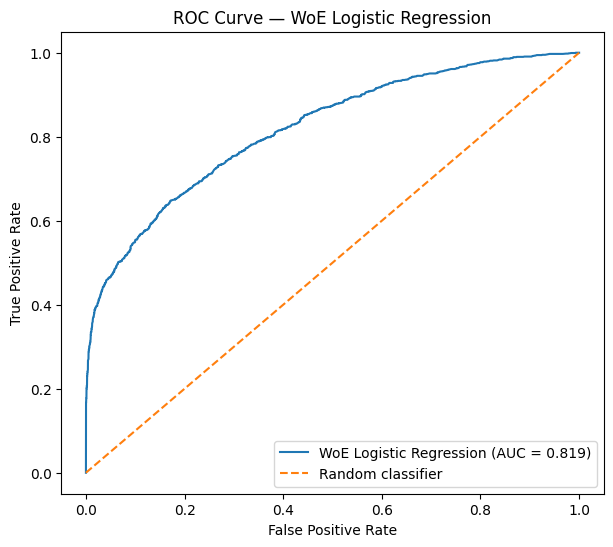

In [101]:
#B89 — ROC curve
# B89 — Plot ROC curve on TEST

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_pd
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"WoE Logistic Regression (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — WoE Logistic Regression")
plt.legend()

plt.show()

In [102]:
#B90 — KS statistic
# B90 — Calculate KS statistic

import numpy as np

ks_values = tpr - fpr

ks_stat = np.max(ks_values)

ks_index = np.argmax(ks_values)

ks_threshold = thresholds[ks_index]

print(
    "KS statistic:",
    round(ks_stat, 4)
)

print(
    "Threshold at max KS:",
    round(ks_threshold, 4)
)

KS statistic: 0.4763
Threshold at max KS: 0.26


In [103]:
#B91 — tạo bảng performance đầu tiên
# B91 — Initial discrimination summary

performance_summary = pd.DataFrame({
    "sample": [
        "Train",
        "Test"
    ],
    "roc_auc": [
        train_auc,
        test_auc
    ],
    "gini": [
        train_gini,
        test_gini
    ]
})

performance_summary

,sample,roc_auc,gini
0,Train,0.816444,0.632889
1,Test,0.818966,0.637931


Baseline Model — Discrimination Results

The baseline WoE Logistic Regression model achieved a ROC-AUC of 0.8164 on the training sample and 0.8190 on the holdout test sample, corresponding to Gini coefficients of 0.6329 and 0.6379, respectively. The close train-test performance provides no apparent evidence of material overfitting in discrimination.

On the test sample, the model achieved a maximum KS statistic of 0.4763, with the maximum separation occurring at a predicted PD threshold of approximately 0.26. This threshold is reported as a statistical diagnostic and is not interpreted as a lending decision cutoff.

The average predicted PD on the test sample was 21.89%, compared with an observed default rate of 21.88%. While these aggregate values are closely aligned, calibration across the PD distribution requires further assessment.

In [104]:
#B92 — Calibration by PD decile
# B92 — Calibration by predicted-PD decile

calibration_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted_pd": test_pd
})

# 10 groups based on predicted PD
# 1 = lowest predicted risk, 10 = highest predicted risk
calibration_df["pd_decile"] = pd.qcut(
    calibration_df["predicted_pd"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

calibration_table = (
    calibration_df
    .groupby("pd_decile", observed=True)
    .agg(
        n_borrowers=("actual", "size"),
        n_defaults=("actual", "sum"),
        avg_predicted_pd=("predicted_pd", "mean"),
        observed_default_rate=("actual", "mean")
    )
    .reset_index()
)

calibration_table["avg_predicted_pd_pct"] = (
    calibration_table["avg_predicted_pd"] * 100
)

calibration_table["observed_default_rate_pct"] = (
    calibration_table["observed_default_rate"] * 100
)

calibration_table[
    [
        "pd_decile",
        "n_borrowers",
        "n_defaults",
        "avg_predicted_pd_pct",
        "observed_default_rate_pct"
    ]
]

,pd_decile,n_borrowers,n_defaults,avg_predicted_pd_pct,observed_default_rate_pct
0,1,654,14,2.264071,2.140673
1,2,645,38,3.952665,5.891473
2,3,649,43,5.682986,6.625578
3,4,645,73,7.820096,11.317829
4,5,651,82,10.900987,12.596006
5,6,645,98,15.130406,15.193798
6,7,650,128,20.405442,19.692308
7,8,653,157,29.326062,24.042879
8,9,641,231,45.694552,36.037441
9,10,649,554,77.948906,85.362096


In [105]:
#B93 — Thêm calibration gap
# B93 — Calibration gap by decile

calibration_table["calibration_gap"] = (
    calibration_table["avg_predicted_pd"]
    - calibration_table["observed_default_rate"]
)

calibration_table["calibration_gap_pct"] = (
    calibration_table["calibration_gap"] * 100
)

calibration_table[
    [
        "pd_decile",
        "n_borrowers",
        "avg_predicted_pd_pct",
        "observed_default_rate_pct",
        "calibration_gap_pct"
    ]
]

,pd_decile,n_borrowers,avg_predicted_pd_pct,observed_default_rate_pct,calibration_gap_pct
0,1,654,2.264071,2.140673,0.123399
1,2,645,3.952665,5.891473,-1.938808
2,3,649,5.682986,6.625578,-0.942592
3,4,645,7.820096,11.317829,-3.497733
4,5,651,10.900987,12.596006,-1.695020
5,6,645,15.130406,15.193798,-0.063392
6,7,650,20.405442,19.692308,0.713134
7,8,653,29.326062,24.042879,5.283183
8,9,641,45.694552,36.037441,9.657110
9,10,649,77.948906,85.362096,-7.413190


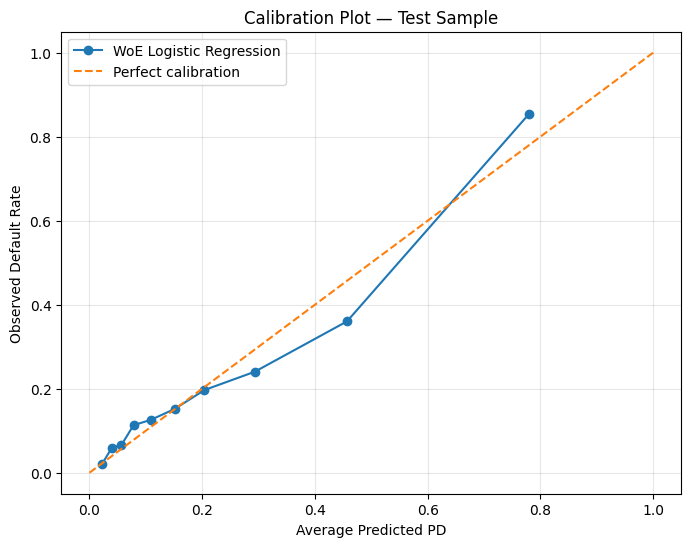

In [106]:
#B94 — Calibration plot
# B94 — Calibration plot by PD decile

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    calibration_table["avg_predicted_pd"],
    calibration_table["observed_default_rate"],
    marker="o",
    label="WoE Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Average Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Plot — Test Sample")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [107]:
#B95 — Brier Score
# B95 — Brier Score

from sklearn.metrics import brier_score_loss

test_brier = brier_score_loss(
    y_test,
    test_pd
)

train_brier = brier_score_loss(
    y_train,
    train_pd
)

print(
    "Train Brier Score:",
    round(train_brier, 4)
)

print(
    "Test Brier Score:",
    round(test_brier, 4)
)

Train Brier Score: 0.1178
Test Brier Score: 0.1174


In [108]:
#B96 — So sánh với naive/base-rate predictor
# B96 — Compare model Brier Score with base-rate benchmark

base_rate = y_train.mean()

baseline_test_pd = np.full(
    len(y_test),
    base_rate
)

baseline_brier = brier_score_loss(
    y_test,
    baseline_test_pd
)

brier_improvement = (
    (baseline_brier - test_brier)
    / baseline_brier
)

print(
    "Training base default rate:",
    f"{base_rate:.2%}"
)

print(
    "Baseline Brier Score:",
    round(baseline_brier, 4)
)

print(
    "Model Brier Score:",
    round(test_brier, 4)
)

print(
    "Relative Brier improvement:",
    f"{brier_improvement:.2%}"
)

Training base default rate: 21.87%
Baseline Brier Score: 0.1709
Model Brier Score: 0.1174
Relative Brier improvement: 31.30%


In [109]:
#B97 — Calibration-in-the-large
# B97 — Calibration-in-the-large

avg_predicted_pd = test_pd.mean()
observed_default_rate = y_test.mean()

calibration_in_large_gap = (
    avg_predicted_pd
    - observed_default_rate
)

print(
    "Average predicted PD:",
    f"{avg_predicted_pd:.4%}"
)

print(
    "Observed default rate:",
    f"{observed_default_rate:.4%}"
)

print(
    "Aggregate calibration gap:",
    f"{calibration_in_large_gap:.4%}"
)

Average predicted PD: 21.8930%
Observed default rate: 21.8760%
Aggregate calibration gap: 0.0171%


In [110]:
#PHASE 10 — Risk Segmentation
#B98 — Risk concentration by PD decile
# B98 — Risk concentration by PD decile

risk_segment_table = calibration_table.copy()

risk_segment_table["borrower_share_pct"] = (
    risk_segment_table["n_borrowers"]
    / risk_segment_table["n_borrowers"].sum()
    * 100
)

risk_segment_table["default_share_pct"] = (
    risk_segment_table["n_defaults"]
    / risk_segment_table["n_defaults"].sum()
    * 100
)

risk_segment_table[
    [
        "pd_decile",
        "n_borrowers",
        "borrower_share_pct",
        "n_defaults",
        "default_share_pct",
        "avg_predicted_pd_pct",
        "observed_default_rate_pct"
    ]
]

,pd_decile,n_borrowers,borrower_share_pct,n_defaults,default_share_pct,avg_predicted_pd_pct,observed_default_rate_pct
0,1,654,10.089479,14,0.987306,2.264071,2.140673
1,2,645,9.950633,38,2.679831,3.952665,5.891473
2,3,649,10.012342,43,3.032440,5.682986,6.625578
3,4,645,9.950633,73,5.148096,7.820096,11.317829
4,5,651,10.043197,82,5.782793,10.900987,12.596006
5,6,645,9.950633,98,6.911142,15.130406,15.193798
6,7,650,10.027769,128,9.026798,20.405442,19.692308
7,8,653,10.074051,157,11.071932,29.326062,24.042879
8,9,641,9.888923,231,16.290550,45.694552,36.037441
9,10,649,10.012342,554,39.069111,77.948906,85.362096


In [111]:
#B99 — Cumulative default capture
# B99 — Cumulative default capture from highest-risk borrowers

capture_table = (
    risk_segment_table
    .sort_values(
        "pd_decile",
        ascending=False
    )
    .copy()
)

capture_table["cumulative_borrower_pct"] = (
    capture_table["n_borrowers"].cumsum()
    / capture_table["n_borrowers"].sum()
    * 100
)

capture_table["cumulative_default_capture_pct"] = (
    capture_table["n_defaults"].cumsum()
    / capture_table["n_defaults"].sum()
    * 100
)

capture_table[
    [
        "pd_decile",
        "n_borrowers",
        "n_defaults",
        "observed_default_rate_pct",
        "cumulative_borrower_pct",
        "cumulative_default_capture_pct"
    ]
]

,pd_decile,n_borrowers,n_defaults,observed_default_rate_pct,cumulative_borrower_pct,cumulative_default_capture_pct
9,10,649,554,85.362096,10.012342,39.069111
8,9,641,231,36.037441,19.901265,55.359661
7,8,653,157,24.042879,29.975316,66.431594
6,7,650,128,19.692308,40.003085,75.458392
5,6,645,98,15.193798,49.953718,82.369535
4,5,651,82,12.596006,59.996915,88.152327
3,4,645,73,11.317829,69.947547,93.300423
2,3,649,43,6.625578,79.959889,96.332863
1,2,645,38,5.891473,89.910521,99.012694
0,1,654,14,2.140673,100.000000,100.000000


In [112]:
#B100 — Top-risk capture summary
# B100 — Summarize concentration of defaults in highest-risk segments

top_10 = capture_table.iloc[:1]
top_20 = capture_table.iloc[:2]
top_30 = capture_table.iloc[:3]

summary_capture = pd.DataFrame({
    "segment": [
        "Highest-risk 10%",
        "Highest-risk 20%",
        "Highest-risk 30%"
    ],
    "borrower_share_pct": [
        top_10["n_borrowers"].sum() / len(y_test) * 100,
        top_20["n_borrowers"].sum() / len(y_test) * 100,
        top_30["n_borrowers"].sum() / len(y_test) * 100
    ],
    "default_capture_pct": [
        top_10["n_defaults"].sum() / y_test.sum() * 100,
        top_20["n_defaults"].sum() / y_test.sum() * 100,
        top_30["n_defaults"].sum() / y_test.sum() * 100
    ]
})

summary_capture

,segment,borrower_share_pct,default_capture_pct
0,Highest-risk 10%,10.012342,39.069111
1,Highest-risk 20%,19.901265,55.359661
2,Highest-risk 30%,29.975316,66.431594


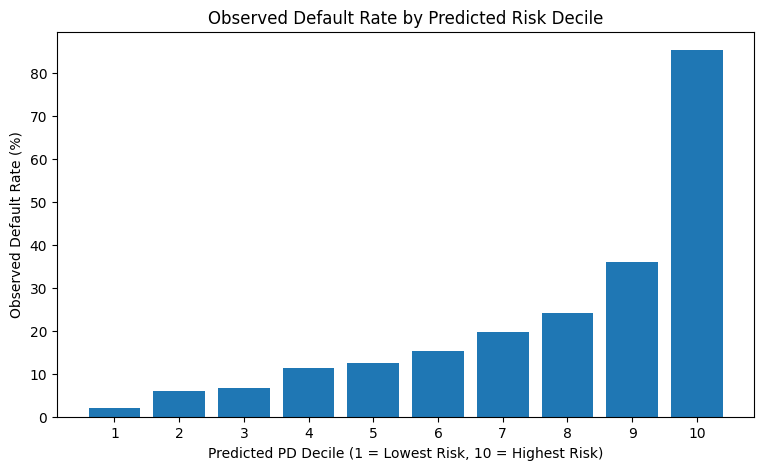

In [113]:
#B101 — Plot observed default rate by risk decile
# B101 — Observed default rate across model risk deciles

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    risk_segment_table["pd_decile"].astype(str),
    risk_segment_table["observed_default_rate_pct"]
)

plt.xlabel("Predicted PD Decile (1 = Lowest Risk, 10 = Highest Risk)")
plt.ylabel("Observed Default Rate (%)")
plt.title("Observed Default Rate by Predicted Risk Decile")

plt.show()

In [114]:
#PHASE 11 — Classification diagnostics
# B102 — Classification diagnostics at max-KS threshold
# IMPORTANT:
# This threshold is used only for diagnostic purposes.
# It is NOT interpreted as an approval/rejection policy cutoff.

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

diagnostic_threshold = ks_threshold

test_pred_class = (
    test_pd >= diagnostic_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    test_pred_class
)

print(
    "Diagnostic threshold:",
    round(diagnostic_threshold, 4)
)

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_pred_class,
        digits=4
    )
)

Diagnostic threshold: 0.26

Confusion matrix:
[[4194  870]
 [ 499  919]]

Classification report:
              precision    recall  f1-score   support

           0     0.8937    0.8282    0.8597      5064
           1     0.5137    0.6481    0.5731      1418

    accuracy                         0.7888      6482
   macro avg     0.7037    0.7381    0.7164      6482
weighted avg     0.8105    0.7888    0.7970      6482



In [115]:
#B103 — Extract metrics
# B103 — Classification metric summary

diagnostic_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "value": [
        accuracy_score(y_test, test_pred_class),
        precision_score(y_test, test_pred_class),
        recall_score(y_test, test_pred_class),
        f1_score(y_test, test_pred_class)
    ]
})

diagnostic_metrics

,metric,value
0,Accuracy,0.788800
1,Precision,0.513695
2,Recall,0.648096
3,F1 Score,0.573121


In [116]:
#PHASE 12 — Sensitivity Analysis
#B104 — Tạo WoE cho interest rate
# B104 — Learn interest-rate bins from TRAIN only

_, rate_edges = pd.qcut(
    train_df["loan_int_rate"].dropna(),
    q=5,
    retbins=True,
    duplicates="drop"
)

rate_edges[0] = -np.inf
rate_edges[-1] = np.inf

print("Interest-rate bin edges:")
print(rate_edges)

Interest-rate bin edges:
[ -inf  7.51 10.25 11.86 13.98   inf]


In [117]:
#B105 — Fit interest-rate WoE
# B105 — Fit interest-rate WoE using TRAIN only

train_rate_bins = pd.cut(
    train_df["loan_int_rate"],
    bins=rate_edges,
    include_lowest=True
).astype(str)

train_rate_bins.loc[
    train_df["loan_int_rate"].isna()
] = "MISSING"

train_rate_temp = pd.DataFrame({
    "bin": train_rate_bins,
    "loan_status": y_train
})

rate_table, rate_woe_mapping, rate_final_iv = (
    fit_woe_from_bins(
        train_rate_temp,
        "bin"
    )
)

print(rate_table)
print("\nInterest Rate IV:", rate_final_iv)

              bin  total   bad  good  dist_good  dist_bad       woe  \
0    (-inf, 7.51]   4710   413  4297   0.212124  0.072840  1.068904   
1  (10.25, 11.86]   4565   779  3786   0.186898  0.137390  0.307741   
2  (11.86, 13.98]   4773   979  3794   0.187293  0.172663  0.081333   
3    (13.98, inf]   4597  2349  2248   0.110974  0.414286 -1.317253   
4   (7.51, 10.25]   4819   641  4178   0.206250  0.113051  0.601243   
5         MISSING   2463   509  1954   0.096460  0.089771  0.071874   

   iv_component  default_rate_pct  
0      0.148882          8.768577  
1      0.015236         17.064622  
2      0.001190         20.511209  
3      0.399538         51.098543  
4      0.056035         13.301515  
5      0.000481         20.665855  

Interest Rate IV: 0.6213620103617556


In [118]:
#B106 — Transform train/test interest rate
# B106 — Apply TRAIN-derived interest-rate WoE mapping

def transform_rate_woe(df):
    
    bins = pd.cut(
        df["loan_int_rate"],
        bins=rate_edges,
        include_lowest=True
    ).astype(str)

    bins.loc[
        df["loan_int_rate"].isna()
    ] = "MISSING"

    return bins.map(rate_woe_mapping)


train_rate_woe = transform_rate_woe(train_df)
test_rate_woe = transform_rate_woe(test_df)

print("Train missing:", train_rate_woe.isna().sum())
print("Test missing:", test_rate_woe.isna().sum())

Train missing: 0
Test missing: 0


In [119]:
#B107 — Sensitivity Model 1: + Interest Rate
# B107 — Sensitivity Model 1: Main model + loan_int_rate

X_train_interest = X_train_woe.copy()
X_test_interest = X_test_woe.copy()

X_train_interest["loan_int_rate_woe"] = train_rate_woe
X_test_interest["loan_int_rate_woe"] = test_rate_woe

interest_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

interest_model.fit(
    X_train_interest,
    y_train
)

interest_train_pd = interest_model.predict_proba(
    X_train_interest
)[:, 1]

interest_test_pd = interest_model.predict_proba(
    X_test_interest
)[:, 1]

print("Sensitivity interest-rate model fitted.")

Sensitivity interest-rate model fitted.


In [120]:

#B108 — Evaluate + interest rate
# B108 — Evaluate interest-rate sensitivity model

from sklearn.metrics import roc_auc_score

interest_train_auc = roc_auc_score(
    y_train,
    interest_train_pd
)

interest_test_auc = roc_auc_score(
    y_test,
    interest_test_pd
)

interest_train_gini = 2 * interest_train_auc - 1
interest_test_gini = 2 * interest_test_auc - 1

print(
    "Train AUC:",
    round(interest_train_auc, 4)
)

print(
    "Test AUC:",
    round(interest_test_auc, 4)
)

print(
    "Test Gini:",
    round(interest_test_gini, 4)
)

Train AUC: 0.8637
Test AUC: 0.8679
Test Gini: 0.7358


In [121]:
#B109 — WoE cho loan_grade
# B109 — Fit loan-grade WoE using TRAIN only

grade_table, grade_woe_mapping, grade_final_iv = (
    fit_categorical_woe(
        train_df,
        "loan_grade"
    )
)

print(grade_table)
print("\nLoan Grade IV:", grade_final_iv)

  bin  total   bad  good  dist_good  dist_bad       woe  iv_component  \
0   A   8530   855  7675   0.378881  0.150794  0.921307      0.210139   
1   B   8281  1362  6919   0.341561  0.240212  0.352005      0.035675   
2   C   5221  1061  4160   0.205361  0.187125  0.092991      0.001696   
3   D   2890  1707  1183   0.058400  0.301058 -1.639981      0.397956   
4   E    755   494   261   0.012884  0.087125 -1.911260      0.141893   
5   F    196   138    58   0.002863  0.024339 -2.139814      0.045953   
6   G     54    53     1   0.000049  0.009347 -5.223656      0.048570   

   default_rate_pct  
0         10.023447  
1         16.447289  
2         20.321777  
3         59.065744  
4         65.430464  
5         70.408163  
6         98.148148  

Loan Grade IV: 0.8818824149607312


In [122]:
#B110 — Transform grade
# B110 — Apply TRAIN-derived grade WoE mapping

train_grade_woe = (
    train_df["loan_grade"]
    .map(grade_woe_mapping)
)

test_grade_woe = (
    test_df["loan_grade"]
    .map(grade_woe_mapping)
)

print(
    "Train missing:",
    train_grade_woe.isna().sum()
)

print(
    "Test missing:",
    test_grade_woe.isna().sum()
)

Train missing: 0
Test missing: 0


In [123]:
#B111 — Sensitivity Model 2: + Interest Rate + Grade
# B111 — Sensitivity Model 2:
# Main model + loan_int_rate + loan_grade

X_train_grade = X_train_interest.copy()
X_test_grade = X_test_interest.copy()

X_train_grade["loan_grade_woe"] = train_grade_woe
X_test_grade["loan_grade_woe"] = test_grade_woe

grade_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

grade_model.fit(
    X_train_grade,
    y_train
)

grade_train_pd = grade_model.predict_proba(
    X_train_grade
)[:, 1]

grade_test_pd = grade_model.predict_proba(
    X_test_grade
)[:, 1]

grade_train_auc = roc_auc_score(
    y_train,
    grade_train_pd
)

grade_test_auc = roc_auc_score(
    y_test,
    grade_test_pd
)

grade_test_gini = (
    2 * grade_test_auc - 1
)

print(
    "Train AUC:",
    round(grade_train_auc, 4)
)

print(
    "Test AUC:",
    round(grade_test_auc, 4)
)

print(
    "Test Gini:",
    round(grade_test_gini, 4)
)

Train AUC: 0.879
Test AUC: 0.8815
Test Gini: 0.7631


In [124]:
#B112 — Model comparison table
# B112 — Compare baseline and sensitivity models

sensitivity_comparison = pd.DataFrame({
    "model": [
        "Main model",
        "Main + interest rate",
        "Main + interest rate + grade"
    ],

    "n_features": [
        X_train_woe.shape[1],
        X_train_interest.shape[1],
        X_train_grade.shape[1]
    ],

    "train_auc": [
        train_auc,
        interest_train_auc,
        grade_train_auc
    ],

    "test_auc": [
        test_auc,
        interest_test_auc,
        grade_test_auc
    ]
})

sensitivity_comparison["test_gini"] = (
    2 * sensitivity_comparison["test_auc"] - 1
)

sensitivity_comparison["auc_gain_vs_main"] = (
    sensitivity_comparison["test_auc"]
    - test_auc
)

sensitivity_comparison.round(4)

,model,n_features,train_auc,test_auc,test_gini,auc_gain_vs_main
0,Main model,6,0.8164,0.8190,0.6379,0.0000
1,Main + interest rate,7,0.8637,0.8679,0.7358,0.0489
2,Main + interest rate + grade,8,0.8790,0.8815,0.7631,0.0626


In [125]:
#B113 — Coefficient check của sensitivity model
# B113 — Coefficients of full sensitivity model

grade_coef_table = (
    pd.DataFrame({
        "feature": X_train_grade.columns,
        "coefficient": grade_model.coef_[0]
    })
    .assign(
        abs_coefficient=lambda x:
        x["coefficient"].abs()
    )
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

grade_coef_table

,feature,coefficient,abs_coefficient
0,loan_intent_woe,-1.480056,1.480056
1,loan_grade_woe,-1.178464,1.178464
2,loan_percent_income_woe,-1.076420,1.076420
3,person_home_ownership_woe,-0.944177,0.944177
4,person_income_woe,-0.715405,0.715405
5,person_emp_length_woe,-0.493006,0.493006
6,loan_int_rate_woe,-0.083453,0.083453
7,previous_default_woe,0.044295,0.044295


#PHASE 13 — Population Stability / PSI
Train/test là random stratified split, không phải out-of-time validation. PSI ở đây nhằm demonstrate monitoring methodology, không phải bằng chứng production temporal stability.

In [126]:
#B114 — PSI function
# B114 — Population Stability Index function

def calculate_psi(expected, actual, bins=10, epsilon=1e-6):
    """
    Calculate PSI between expected (reference) and actual samples.

    For this project:
    expected = training sample
    actual   = test sample

    Note:
    Train/test were randomly split, so this demonstrates the
    PSI monitoring methodology rather than temporal stability.
    """

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    # Learn bin edges from reference sample only
    _, bin_edges = pd.qcut(
        expected,
        q=bins,
        retbins=True,
        duplicates="drop"
    )

    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    expected_bins = pd.cut(
        expected,
        bins=bin_edges,
        include_lowest=True
    )

    actual_bins = pd.cut(
        actual,
        bins=bin_edges,
        include_lowest=True
    )

    expected_dist = (
        expected_bins.value_counts(sort=False)
        / len(expected)
    )

    actual_dist = (
        actual_bins.value_counts(sort=False)
        / len(actual)
    )

    expected_dist = expected_dist.clip(lower=epsilon)
    actual_dist = actual_dist.clip(lower=epsilon)

    psi_components = (
        (actual_dist - expected_dist)
        * np.log(actual_dist / expected_dist)
    )

    psi_table = pd.DataFrame({
        "expected_pct": expected_dist * 100,
        "actual_pct": actual_dist * 100,
        "psi_component": psi_components
    })

    psi_value = psi_components.sum()

    return psi_value, psi_table

In [127]:
#B115 — PSI cho toàn bộ main-model features
# B115 — Calculate PSI for main-model WoE features

psi_results = []

for feature in X_train_woe.columns:

    psi_value, _ = calculate_psi(
        X_train_woe[feature],
        X_test_woe[feature]
    )

    psi_results.append({
        "feature": feature,
        "psi": psi_value
    })

psi_summary = (
    pd.DataFrame(psi_results)
    .sort_values("psi", ascending=False)
    .reset_index(drop=True)
)

psi_summary

,feature,psi
0,loan_intent_woe,0.000935
1,person_income_woe,0.000401
2,person_home_ownership_woe,0.000238
3,person_emp_length_woe,0.000179
4,loan_percent_income_woe,0.000037
5,previous_default_woe,0.000000


In [128]:
#B116 — Thêm interpretation band
# B116 — Add heuristic PSI interpretation

def interpret_psi(psi):
    if psi < 0.10:
        return "Low shift"
    elif psi < 0.25:
        return "Moderate shift"
    else:
        return "High shift"


psi_summary["interpretation"] = (
    psi_summary["psi"]
    .apply(interpret_psi)
)

psi_summary

,feature,psi,interpretation
0,loan_intent_woe,0.000935,Low shift
1,person_income_woe,0.000401,Low shift
2,person_home_ownership_woe,0.000238,Low shift
3,person_emp_length_woe,0.000179,Low shift
4,loan_percent_income_woe,0.000037,Low shift
5,previous_default_woe,0.000000,Low shift


In [129]:
#B117 — Inspect feature có PSI cao nhất
# B117 — Inspect distribution of feature with highest PSI

highest_psi_feature = psi_summary.iloc[0]["feature"]

highest_psi_value, highest_psi_table = (
    calculate_psi(
        X_train_woe[highest_psi_feature],
        X_test_woe[highest_psi_feature]
    )
)

print("Feature:", highest_psi_feature)
print("PSI:", round(highest_psi_value, 6))
print()

highest_psi_table

Feature: loan_intent_woe
PSI: 0.000935



,expected_pct,actual_pct,psi_component
loan_intent_woe,,,
"(-inf, -0.255]",27.153161,26.889849,0.000026
"(-0.255, -0.252]",18.517376,19.145326,0.000209
"(-0.252, 0.133]",17.013152,16.738661,0.000045
"(0.133, 0.297]",19.940602,19.114471,0.000350
"(0.297, inf]",17.375709,18.111694,0.000305


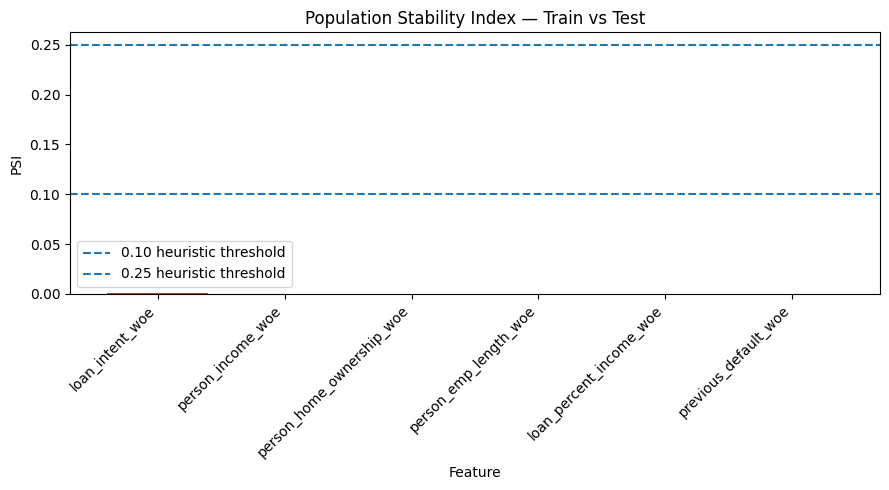

In [130]:
#B118 — PSI bar chart
# B118 — PSI summary visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    psi_summary["feature"],
    psi_summary["psi"]
)

plt.axhline(
    0.10,
    linestyle="--",
    label="0.10 heuristic threshold"
)

plt.axhline(
    0.25,
    linestyle="--",
    label="0.25 heuristic threshold"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("PSI")
plt.xlabel("Feature")
plt.title("Population Stability Index — Train vs Test")
plt.legend()
plt.tight_layout()
plt.show()

In [131]:
#B119 — Monitoring framework
# B119 — Model monitoring framework

monitoring_framework = pd.DataFrame({
    "monitoring_area": [
        "Population stability",
        "Discrimination",
        "Rank ordering",
        "Calibration",
        "Portfolio risk level"
    ],

    "metric": [
        "PSI",
        "ROC-AUC / Gini / KS",
        "Observed default rate by risk decile",
        "Predicted PD vs observed default rate / Brier Score",
        "Average predicted PD and observed default rate"
    ],

    "purpose": [
        "Detect shifts in borrower / feature distributions",
        "Monitor ability to separate defaults from non-defaults",
        "Check whether higher predicted risk corresponds to higher realized default",
        "Assess accuracy of predicted probabilities",
        "Monitor changes in overall portfolio risk"
    ]
})

monitoring_framework

,monitoring_area,metric,purpose
0,Population stability,PSI,Detect shifts in borrower / feature distributions
1,Discrimination,ROC-AUC / Gini / KS,Monitor ability to separate defaults from non-...
2,Rank ordering,Observed default rate by risk decile,Check whether higher predicted risk correspond...
3,Calibration,Predicted PD vs observed default rate / Brier ...,Assess accuracy of predicted probabilities
4,Portfolio risk level,Average predicted PD and observed default rate,Monitor changes in overall portfolio risk


In [132]:
#PHASE 14 — Final Model Validation Summary
# B120 — Final model performance summary

from sklearn.metrics import brier_score_loss

# Recalculate calibration metrics to avoid dependency on old variables
train_brier = brier_score_loss(y_train, train_pd)
test_brier = brier_score_loss(y_test, test_pd)

# Baseline = predict training default rate for every test borrower
base_rate = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    base_rate
)

baseline_brier = brier_score_loss(
    y_test,
    baseline_predictions
)

relative_brier_improvement = (
    (baseline_brier - test_brier)
    / baseline_brier
)

# Final summary
final_performance = pd.DataFrame({
    "metric": [
        "Train ROC-AUC",
        "Test ROC-AUC",
        "Train Gini",
        "Test Gini",
        "Test KS",
        "Test Brier Score",
        "Baseline Brier Score",
        "Relative Brier Improvement",
        "Average Predicted PD",
        "Observed Default Rate"
    ],

    "value": [
        train_auc,
        test_auc,
        train_gini,
        test_gini,
        ks_stat,
        test_brier,
        baseline_brier,
        relative_brier_improvement,
        test_pd.mean(),
        y_test.mean()
    ]
})

final_performance

,metric,value
0,Train ROC-AUC,0.816444
1,Test ROC-AUC,0.818966
2,Train Gini,0.632889
3,Test Gini,0.637931
4,Test KS,0.476295
5,Test Brier Score,0.117407
6,Baseline Brier Score,0.170904
7,Relative Brier Improvement,0.313023
8,Average Predicted PD,0.218930
9,Observed Default Rate,0.218760


In [133]:
## B121 — Risk concentration summary

risk_concentration_summary = pd.DataFrame({
    "segment": [
        "Highest-risk 10%",
        "Highest-risk 20%",
        "Highest-risk 30%"
    ],

    "borrower_share_pct": [
        10.012342,
        19.901265,
        29.975316
    ],

    "default_capture_pct": [
        39.069111,
        55.359661,
        66.431594
    ]
})

risk_concentration_summary

,segment,borrower_share_pct,default_capture_pct
0,Highest-risk 10%,10.012342,39.069111
1,Highest-risk 20%,19.901265,55.359661
2,Highest-risk 30%,29.975316,66.431594


In [134]:
# B122 — Sensitivity-analysis summary

final_sensitivity = (
    sensitivity_comparison[
        [
            "model",
            "n_features",
            "train_auc",
            "test_auc",
            "test_gini",
            "auc_gain_vs_main"
        ]
    ]
    .copy()
)

final_sensitivity.round(4)

,model,n_features,train_auc,test_auc,test_gini,auc_gain_vs_main
0,Main model,6,0.8164,0.8190,0.6379,0.0000
1,Main + interest rate,7,0.8637,0.8679,0.7358,0.0489
2,Main + interest rate + grade,8,0.8790,0.8815,0.7631,0.0626


In [135]:
# B123 — Model development decisions

model_decisions = pd.DataFrame({
    "decision_area": [
        "Target",
        "Development sample",
        "Feature transformation",
        "Main model",
        "Interest rate",
        "Loan grade",
        "Missing employment length",
        "Validation",
        "Monitoring"
    ],

    "decision": [
        "loan_status (1 = default, 0 = non-default)",
        "80/20 stratified random train-test split",
        "WoE transformations learned from TRAIN only",
        "6-feature WoE Logistic Regression",
        "Excluded from main model; sensitivity analysis only",
        "Excluded from main model; sensitivity analysis only",
        "Retained as a separate risk-information bin",
        "Discrimination, calibration, rank ordering and diagnostic classification",
        "PSI framework plus performance and calibration monitoring"
    ],

    "rationale": [
        "Binary credit-risk outcome available in the dataset",
        "Preserves approximately equal default prevalence across samples",
        "Reduces leakage and maintains consistent out-of-sample transformation",
        "Interpretable baseline using borrower and loan characteristics",
        "Potential pricing / underwriting information",
        "Potential existing underwriting / risk information",
        "Missingness showed different observed default behavior",
        "Evaluate multiple dimensions rather than accuracy alone",
        "Demonstrate model monitoring framework"
    ]
})

model_decisions

,decision_area,decision,rationale
0,Target,"loan_status (1 = default, 0 = non-default)",Binary credit-risk outcome available in the da...
1,Development sample,80/20 stratified random train-test split,Preserves approximately equal default prevalen...
2,Feature transformation,WoE transformations learned from TRAIN only,Reduces leakage and maintains consistent out-o...
3,Main model,6-feature WoE Logistic Regression,Interpretable baseline using borrower and loan...
4,Interest rate,Excluded from main model; sensitivity analysis...,Potential pricing / underwriting information
5,Loan grade,Excluded from main model; sensitivity analysis...,Potential existing underwriting / risk informa...
6,Missing employment length,Retained as a separate risk-information bin,Missingness showed different observed default ...
7,Validation,"Discrimination, calibration, rank ordering and...",Evaluate multiple dimensions rather than accur...
8,Monitoring,PSI framework plus performance and calibration...,Demonstrate model monitoring framework


In [136]:
# B124 — Project limitations

limitations = pd.DataFrame({
    "limitation": [
        "Public dataset",
        "Random validation split",
        "Observed target definition",
        "Potential underwriting variables",
        "Probability calibration",
        "Limited model benchmarking",
        "Regulatory scope"
    ],

    "implication": [
        "Results may not represent a real bank portfolio or current lending population.",
        "Test performance does not demonstrate out-of-time stability.",
        "loan_status is treated as the observed default outcome available in the dataset and is not a regulatory default definition.",
        "loan_int_rate and loan_grade may contain pricing or prior underwriting information and were therefore excluded from the main model.",
        "Aggregate calibration is strong, but several risk deciles show local calibration gaps.",
        "The project focuses on an interpretable WoE Logistic Regression rather than an exhaustive challenger-model exercise.",
        "The model is an educational credit-risk exercise and is not a Basel or IFRS 9 regulatory PD model."
    ]
})

limitations

,limitation,implication
0,Public dataset,Results may not represent a real bank portfoli...
1,Random validation split,Test performance does not demonstrate out-of-t...
2,Observed target definition,loan_status is treated as the observed default...
3,Potential underwriting variables,loan_int_rate and loan_grade may contain prici...
4,Probability calibration,"Aggregate calibration is strong, but several r..."
5,Limited model benchmarking,The project focuses on an interpretable WoE Lo...
6,Regulatory scope,The model is an educational credit-risk exerci...


In [137]:
# B125 — Final project conclusion

print("CREDIT RISK MODEL — FINAL VALIDATION SUMMARY")
print("=" * 55)

print(f"Development observations: {len(train_df):,}")
print(f"Test observations:        {len(test_df):,}")
print(f"Test default rate:        {y_test.mean():.2%}")

print("\nDISCRIMINATION")
print(f"Test ROC-AUC:             {test_auc:.4f}")
print(f"Test Gini:                {test_gini:.4f}")
print(f"Test KS:                  {ks_stat:.4f}")

print("\nCALIBRATION")
print(f"Test Brier Score:         {test_brier:.4f}")
print(f"Average predicted PD:     {test_pd.mean():.2%}")
print(f"Observed default rate:    {y_test.mean():.2%}")

print("\nRISK CONCENTRATION")
print("Highest-risk 10% captures 39.07% of observed defaults")
print("Highest-risk 20% captures 55.36% of observed defaults")
print("Highest-risk 30% captures 66.43% of observed defaults")

print("\nSENSITIVITY")
print("Main model AUC:                       0.8190")
print("Main + interest rate AUC:             0.8679")
print("Main + interest rate + grade AUC:     0.8815")

print("\nPOPULATION STABILITY")
print(f"Maximum train-test PSI: {psi_summary['psi'].max():.6f}")

print("\nFINAL MODEL")
print("6-feature WoE Logistic Regression")

CREDIT RISK MODEL — FINAL VALIDATION SUMMARY
Development observations: 25,927
Test observations:        6,482
Test default rate:        21.88%

DISCRIMINATION
Test ROC-AUC:             0.8190
Test Gini:                0.6379
Test KS:                  0.4763

CALIBRATION
Test Brier Score:         0.1174
Average predicted PD:     21.89%
Observed default rate:    21.88%

RISK CONCENTRATION
Highest-risk 10% captures 39.07% of observed defaults
Highest-risk 20% captures 55.36% of observed defaults
Highest-risk 30% captures 66.43% of observed defaults

SENSITIVITY
Main model AUC:                       0.8190
Main + interest rate AUC:             0.8679
Main + interest rate + grade AUC:     0.8815

POPULATION STABILITY
Maximum train-test PSI: 0.000935

FINAL MODEL
6-feature WoE Logistic Regression


In [138]:
# B126A — Inventory existing DataFrames

dataframes = {
    name: obj
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

for name, df in dataframes.items():
    print(
        f"{name:<35} "
        f"shape={str(df.shape):<15} "
        f"columns={df.columns.tolist()}"
    )

_                                   shape=(5, 3)          columns=['expected_pct', 'actual_pct', 'psi_component']
df                                  shape=(32581, 12)     columns=['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
_3                                  shape=(5, 12)         columns=['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
_6                                  shape=(12, 5)         columns=[0, 1, 2, 3, 4]
missing_report                      shape=(2, 2)          columns=['missing_count', 'missing_pct']
_8                                  shape=(2, 2)          columns=['missing_count', 'missing_pct']
_10   

In [139]:
# B126 FINAL — Automatically identify and export project tables

from pathlib import Path
import pandas as pd

output_dir = OUTPUT_DIR
figure_dir = FIGURE_DIR

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. SNAPSHOT ALL DATAFRAMES
# ============================================================

all_dfs = {
    name: obj
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
    and not name.startswith("_")
}


# ============================================================
# 2. HELPER — FIND DATAFRAME BY REQUIRED COLUMNS
# ============================================================

def find_dataframe(required_columns):
    required_columns = set(required_columns)

    matches = []

    for name, df_obj in all_dfs.items():

        if required_columns.issubset(set(df_obj.columns)):
            matches.append((name, df_obj))

    return matches


# ============================================================
# 3. DEFINE TABLE SCHEMAS
# ============================================================

table_specs = {

    "pd_decile_analysis.csv": [
        "pd_decile",
        "n_borrowers",
        "avg_predicted_pd_pct",
        "observed_default_rate_pct"
    ],

    "default_capture_summary.csv": [
        "segment",
        "borrower_share_pct",
        "default_capture_pct"
    ],

    "model_sensitivity_comparison.csv": [
        "model",
        "n_features",
        "train_auc",
        "test_auc",
        "test_gini"
    ],

    "psi_summary.csv": [
        "feature",
        "psi"
    ],

    "feature_iv_summary.csv": [
        "feature",
        "iv"
    ],

    "logistic_regression_coefficients.csv": [
        "feature",
        "coefficient",
        "abs_coefficient"
    ],

    "model_development_decisions.csv": [
        "decision_area",
        "decision",
        "rationale"
    ],

    "project_limitations.csv": [
        "limitation",
        "implication"
    ]
}


# ============================================================
# 4. EXPORT FINAL METRICS DIRECTLY
# ============================================================

if "final_metrics" in globals():

    final_metrics.to_csv(
        output_dir / "final_model_metrics.csv",
        index=False
    )

    print(
        "[OK] final_model_metrics.csv",
        "<- final_metrics"
    )

else:
    print("[NOT FOUND] final_metrics")


# ============================================================
# 5. AUTO-DETECT AND EXPORT OTHER TABLES
# ============================================================

for filename, required_columns in table_specs.items():

    matches = find_dataframe(required_columns)

    if len(matches) == 0:

        print(
            f"[NOT FOUND] {filename}"
        )

    else:

        # Prefer the most recently created matching DataFrame
        variable_name, dataframe = matches[-1]

        dataframe.to_csv(
            output_dir / filename,
            index=False
        )

        print(
            f"[OK] {filename:<40} "
            f"<- {variable_name} "
            f"{dataframe.shape}"
        )


# ============================================================
# 6. VERIFY FILES
# ============================================================

print("\n" + "=" * 70)
print("EXPORTED FILES")
print("=" * 70)

for file in sorted(output_dir.glob("*.csv")):

    size_kb = file.stat().st_size / 1024

    print(
        f"{file.name:<45} "
        f"{size_kb:.2f} KB"
    )

[NOT FOUND] final_metrics
[OK] pd_decile_analysis.csv                   <- top_30 (3, 13)
[OK] default_capture_summary.csv              <- risk_concentration_summary (3, 3)
[OK] model_sensitivity_comparison.csv         <- final_sensitivity (3, 6)
[OK] psi_summary.csv                          <- psi_summary (6, 3)
[OK] feature_iv_summary.csv                   <- final_iv_summary (6, 2)
[OK] logistic_regression_coefficients.csv     <- grade_coef_table (8, 3)
[OK] model_development_decisions.csv          <- model_decisions (9, 3)
[OK] project_limitations.csv                  <- limitations (7, 2)

EXPORTED FILES
default_capture_summary.csv                   0.16 KB
feature_iv_summary.csv                        0.24 KB
final_model_metrics.csv                       0.37 KB
logistic_regression_coefficients.csv          0.50 KB
model_development_decisions.csv               1.09 KB
model_sensitivity_comparison.csv              0.34 KB
pd_decile_analysis.csv                        0.83 KB
proje

In [140]:
# B126C — Correct incorrectly auto-detected exports

# ============================================================
# 1. FIND THE FULL 10-DECILE TABLE
# ============================================================

decile_candidates = []

for name, obj in list(globals().items()):

    if (
        isinstance(obj, pd.DataFrame)
        and not name.startswith("_")
        and "pd_decile" in obj.columns
        and "avg_predicted_pd_pct" in obj.columns
        and "observed_default_rate_pct" in obj.columns
        and len(obj) == 10
    ):
        decile_candidates.append((name, obj))


print("10-decile candidates:")

for name, obj in decile_candidates:
    print(name, obj.shape)


# Export if exactly one suitable table is found
if len(decile_candidates) >= 1:

    decile_name, full_decile_table = decile_candidates[-1]

    full_decile_table.to_csv(
        output_dir / "pd_decile_analysis.csv",
        index=False
    )

    print(
        "\n[FIXED] pd_decile_analysis.csv <-",
        decile_name,
        full_decile_table.shape
    )

else:
    print("\n[NOT FOUND] Full 10-decile table")


# ============================================================
# 2. EXPORT MAIN MODEL COEFFICIENTS
# ============================================================

print("\nMain coefficient table:")
print(coef_table)

assert len(coef_table) == 6, (
    f"Expected 6 main-model coefficients, "
    f"found {len(coef_table)}"
)

coef_table.to_csv(
    output_dir / "logistic_regression_coefficients.csv",
    index=False
)

print(
    "\n[FIXED] logistic_regression_coefficients.csv <- "
    "coef_table",
    coef_table.shape
)


# ============================================================
# 3. VERIFY
# ============================================================

check_decile = pd.read_csv(
    output_dir / "pd_decile_analysis.csv"
)

check_coef = pd.read_csv(
    output_dir / "logistic_regression_coefficients.csv"
)

print("\n" + "=" * 60)
print("FINAL CHECK")
print("=" * 60)

print(
    "PD decile rows:",
    len(check_decile)
)

print(
    "Main coefficient rows:",
    len(check_coef)
)

print(
    "Deciles:",
    check_decile["pd_decile"].tolist()
)

print(
    "Coefficient features:",
    check_coef["feature"].tolist()
)

10-decile candidates:
calibration_table (10, 9)
risk_segment_table (10, 11)
capture_table (10, 13)

[FIXED] pd_decile_analysis.csv <- capture_table (10, 13)

Main coefficient table:
                     feature  coefficient  abs_coefficient
0            loan_intent_woe    -1.291771         1.291771
1       previous_default_woe    -1.183825         1.183825
2    loan_percent_income_woe    -1.008387         1.008387
3  person_home_ownership_woe    -0.905835         0.905835
4          person_income_woe    -0.559749         0.559749
5      person_emp_length_woe    -0.369982         0.369982

[FIXED] logistic_regression_coefficients.csv <- coef_table (6, 3)

FINAL CHECK
PD decile rows: 10
Main coefficient rows: 6
Deciles: [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Coefficient features: ['loan_intent_woe', 'previous_default_woe', 'loan_percent_income_woe', 'person_home_ownership_woe', 'person_income_woe', 'person_emp_length_woe']


In [141]:
# B126D — Sort exported PD decile table from low risk to high risk

pd_decile_export = (
    capture_table
    .sort_values("pd_decile", ascending=True)
    .reset_index(drop=True)
)

pd_decile_export.to_csv(
    output_dir / "pd_decile_analysis.csv",
    index=False
)

# Verify
check_decile = pd.read_csv(
    output_dir / "pd_decile_analysis.csv"
)

print(
    "Final decile order:",
    check_decile["pd_decile"].tolist()
)

Final decile order: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [142]:
# B127A — Find all Logistic Regression model objects

from sklearn.linear_model import LogisticRegression

lr_models = []

for name, obj in list(globals().items()):
    if isinstance(obj, LogisticRegression):
        lr_models.append((name, obj))

print(f"Found {len(lr_models)} Logistic Regression model(s):\n")

for name, model in lr_models:
    print("=" * 60)
    print("VARIABLE:", name)
    print("Number of features:", model.n_features_in_)
    
    if hasattr(model, "feature_names_in_"):
        print("Features:")
        for feature in model.feature_names_in_:
            print("  -", feature)

Found 3 Logistic Regression model(s):

VARIABLE: logit_model
Number of features: 6
Features:
  - loan_percent_income_woe
  - person_income_woe
  - person_home_ownership_woe
  - previous_default_woe
  - loan_intent_woe
  - person_emp_length_woe
VARIABLE: interest_model
Number of features: 7
Features:
  - loan_percent_income_woe
  - person_income_woe
  - person_home_ownership_woe
  - previous_default_woe
  - loan_intent_woe
  - person_emp_length_woe
  - loan_int_rate_woe
VARIABLE: grade_model
Number of features: 8
Features:
  - loan_percent_income_woe
  - person_income_woe
  - person_home_ownership_woe
  - previous_default_woe
  - loan_intent_woe
  - person_emp_length_woe
  - loan_int_rate_woe
  - loan_grade_woe


In [143]:
# B127 FINAL — Save final Logistic Regression model

from pathlib import Path
import pickle

model_dir = MODEL_DIR
model_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Define final model explicitly
# ============================================================

final_model = logit_model

expected_features = [
    "loan_percent_income_woe",
    "person_income_woe",
    "person_home_ownership_woe",
    "previous_default_woe",
    "loan_intent_woe",
    "person_emp_length_woe"
]

actual_features = list(final_model.feature_names_in_)

assert actual_features == expected_features, (
    "Feature order does not match expected final-model features."
)

print("[OK] Final model verified")
print("Number of features:", final_model.n_features_in_)


# ============================================================
# 2. Save model
# ============================================================

model_path = model_dir / "woe_logistic_regression.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print("[OK] Saved:", model_path)


# ============================================================
# 3. Save feature order
# ============================================================

feature_path = model_dir / "model_features.pkl"

with open(feature_path, "wb") as f:
    pickle.dump(actual_features, f)

print("[OK] Saved:", feature_path)


# ============================================================
# 4. Reload model to verify serialization
# ============================================================

with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

with open(feature_path, "rb") as f:
    loaded_features = pickle.load(f)

assert loaded_model.n_features_in_ == 6
assert loaded_features == expected_features

print("[OK] Reload verification passed")


# ============================================================
# 5. Compare predictions before vs after saving
# ============================================================

original_pd = final_model.predict_proba(
    X_test_woe[expected_features]
)[:, 1]

loaded_pd = loaded_model.predict_proba(
    X_test_woe[loaded_features]
)[:, 1]

max_difference = abs(original_pd - loaded_pd).max()

print(
    "[OK] Maximum prediction difference after reload:",
    max_difference
)

assert max_difference < 1e-12


# ============================================================
# 6. Show saved artifacts
# ============================================================

print("\n" + "=" * 60)
print("FINAL MODEL ARTIFACTS")
print("=" * 60)

for file in sorted(model_dir.iterdir()):
    print(
        f"{file.name:<35}"
        f"{file.stat().st_size / 1024:.2f} KB"
    )

[OK] Final model verified
Number of features: 6
[OK] Saved: e:\project credit risk\credit_risk_pd\models\woe_logistic_regression.pkl
[OK] Saved: e:\project credit risk\credit_risk_pd\models\model_features.pkl
[OK] Reload verification passed
[OK] Maximum prediction difference after reload: 0.0

FINAL MODEL ARTIFACTS
model_features.pkl                 0.15 KB
preprocessing_artifacts.pkl        1.18 KB
woe_logistic_regression.pkl        0.96 KB


In [144]:
# B128A — Inventory possible WoE mappings and binning artifacts

candidates = []

keywords = [
    "woe",
    "mapping",
    "map",
    "bin",
    "edge",
    "cut"
]

for name, obj in list(globals().items()):

    if name.startswith("_"):
        continue

    name_lower = name.lower()

    if any(keyword in name_lower for keyword in keywords):

        # Keep only objects useful for preprocessing
        if isinstance(
            obj,
            (dict, list, tuple, pd.Series, pd.DataFrame)
        ):
            candidates.append(
                (
                    name,
                    type(obj).__name__,
                    getattr(obj, "shape", None)
                )
            )


print("=" * 75)
print("POSSIBLE PREPROCESSING ARTIFACTS")
print("=" * 75)

for name, obj_type, shape in candidates:

    print(
        f"{name:<40} "
        f"type={obj_type:<12} "
        f"shape={shape}"
    )

POSSIBLE PREPROCESSING ARTIFACTS
train_woe_demo                           type=DataFrame    shape=(25927, 13)
lti_woe                                  type=DataFrame    shape=(5, 10)
income_woe                               type=DataFrame    shape=(5, 9)
emp_woe                                  type=DataFrame    shape=(6, 9)
rate_woe                                 type=DataFrame    shape=(6, 9)
numeric_woe_tables                       type=dict         shape=None
home_woe                                 type=DataFrame    shape=(4, 9)
categorical_woe_tables                   type=dict         shape=None
grade_woe                                type=DataFrame    shape=(7, 9)
lti_edges                                type=list         shape=None
lti_woe_mapping                          type=dict         shape=None
income_woe_mapping                       type=dict         shape=None
emp_woe_mapping                          type=dict         shape=None
home_woe_mapping                     

In [145]:
# B128 — Package final-model preprocessing artifacts

from pathlib import Path
import pickle
import numpy as np
import pandas as pd

model_dir = MODEL_DIR
model_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. FINAL MODEL BIN DEFINITIONS
# ============================================================

# These are the final bin definitions used in the main model.

final_lti_edges = [
    -np.inf,
    0.10,
    0.20,
    0.30,
    0.40,
    np.inf
]

final_income_edges = [
    -np.inf,
    35000,
    48996,
    63000,
    86000,
    np.inf
]

final_emp_edges = [
    -np.inf,
    1,
    3,
    5,
    8,
    np.inf
]


# ============================================================
# 2. PACKAGE ONLY MAIN-MODEL WOE MAPPINGS
# ============================================================

preprocessing_artifacts = {

    "numeric_bins": {
        "loan_percent_income": final_lti_edges,
        "person_income": final_income_edges,
        "person_emp_length": final_emp_edges
    },

    "woe_mappings": {
        "loan_percent_income": lti_woe_mapping,
        "person_income": income_woe_mapping,
        "person_emp_length": emp_woe_mapping,

        "person_home_ownership": home_woe_mapping,
        "cb_person_default_on_file": prev_woe_mapping,
        "loan_intent": intent_woe_mapping
    },

    "model_features": [
        "loan_percent_income_woe",
        "person_income_woe",
        "person_home_ownership_woe",
        "previous_default_woe",
        "loan_intent_woe",
        "person_emp_length_woe"
    ],

    "target": "loan_status",

    "target_definition": {
        0: "non-default",
        1: "observed default"
    },

    "woe_convention": "ln(dist_good / dist_bad)"
}


# ============================================================
# 3. SAVE ARTIFACT
# ============================================================

preprocessing_path = (
    model_dir / "preprocessing_artifacts.pkl"
)

with open(preprocessing_path, "wb") as f:
    pickle.dump(
        preprocessing_artifacts,
        f
    )

print(
    "[OK] Saved:",
    preprocessing_path
)


# ============================================================
# 4. RELOAD TO VERIFY
# ============================================================

with open(preprocessing_path, "rb") as f:
    loaded_preprocessing = pickle.load(f)

assert (
    loaded_preprocessing["model_features"]
    == expected_features
)

print("[OK] Reload verification passed")


# ============================================================
# 5. INSPECT PACKAGE
# ============================================================

print("\nNumeric bin definitions:")

for feature, edges in (
    loaded_preprocessing["numeric_bins"].items()
):
    print(
        f"{feature:<25}",
        edges
    )


print("\nWoE mappings:")

for feature, mapping in (
    loaded_preprocessing["woe_mappings"].items()
):
    print(
        f"{feature:<30}",
        len(mapping),
        "bins/categories"
    )

[OK] Saved: e:\project credit risk\credit_risk_pd\models\preprocessing_artifacts.pkl
[OK] Reload verification passed

Numeric bin definitions:
loan_percent_income       [-inf, 0.1, 0.2, 0.3, 0.4, inf]
person_income             [-inf, 35000, 48996, 63000, 86000, inf]
person_emp_length         [-inf, 1, 3, 5, 8, inf]

WoE mappings:
loan_percent_income            5 bins/categories
person_income                  5 bins/categories
person_emp_length              6 bins/categories
person_home_ownership          4 bins/categories
cb_person_default_on_file      2 bins/categories
loan_intent                    6 bins/categories


In [149]:
# B129 — End-to-end scoring transformation
# Raw borrower data -> bins -> WoE features

def transform_main_model_woe(raw_df, artifacts):

    X = pd.DataFrame(index=raw_df.index)

    mappings = artifacts["woe_mappings"]
    bins = artifacts["numeric_bins"]

    # ========================================================
    # 1. LOAN PERCENT INCOME
    # Mapping uses custom labels
    # ========================================================

    lti_labels = pd.cut(
        raw_df["loan_percent_income"],
        bins=bins["loan_percent_income"],
        labels=[
            "<10%",
            "10-20%",
            "20-30%",
            "30-40%",
            ">40%"
        ],
        include_lowest=True
    )

    X["loan_percent_income_woe"] = (
        lti_labels.astype(object)
        .map(mappings["loan_percent_income"])
        .astype(float)
    )

    # ========================================================
    # 2. PERSON INCOME
    # Mapping keys are interval strings
    # ========================================================

    income_bins = pd.cut(
        raw_df["person_income"],
        bins=bins["person_income"]
    )

    income_keys = income_bins.astype(str)

    X["person_income_woe"] = (
        income_keys
        .map(mappings["person_income"])
        .astype(float)
    )

    # ========================================================
    # 3. HOME OWNERSHIP
    # ========================================================

    X["person_home_ownership_woe"] = (
        raw_df["person_home_ownership"]
        .map(mappings["person_home_ownership"])
        .astype(float)
    )

    # ========================================================
    # 4. PREVIOUS DEFAULT
    # ========================================================

    X["previous_default_woe"] = (
        raw_df["cb_person_default_on_file"]
        .map(mappings["cb_person_default_on_file"])
        .astype(float)
    )

    # ========================================================
    # 5. LOAN INTENT
    # ========================================================

    X["loan_intent_woe"] = (
        raw_df["loan_intent"]
        .map(mappings["loan_intent"])
        .astype(float)
    )

    # ========================================================
    # 6. EMPLOYMENT LENGTH
    # Mapping keys are interval strings + MISSING
    # ========================================================

    emp_bins = pd.cut(
        raw_df["person_emp_length"],
        bins=bins["person_emp_length"]
    )

    emp_keys = emp_bins.astype(str)

    emp_keys = emp_keys.where(
        raw_df["person_emp_length"].notna(),
        "MISSING"
    )

    X["person_emp_length_woe"] = (
        emp_keys
        .map(mappings["person_emp_length"])
        .astype(float)
    )

    # ========================================================
    # FINAL FEATURE ORDER
    # ========================================================

    return X[artifacts["model_features"]]

In [147]:
# ============================================================
# TRANSFORM RAW TEST DATA
# ============================================================

X_test_rebuilt = transform_main_model_woe(
    test_df,
    loaded_preprocessing
)

print(
    "Rebuilt shape:",
    X_test_rebuilt.shape
)

print(
    "Missing values:",
    X_test_rebuilt.isna().sum().sum()
)


# ============================================================
# COMPARE AGAINST ORIGINAL X_test_woe
# ============================================================

original_X = X_test_woe[
    expected_features
].astype(float)

rebuilt_X = X_test_rebuilt[
    expected_features
].astype(float)


feature_difference = (
    original_X - rebuilt_X
).abs()

print(
    "Maximum WoE feature difference:",
    feature_difference.to_numpy().max()
)


# ============================================================
# SCORE WITH RELOADED MODEL
# ============================================================

rebuilt_pd = loaded_model.predict_proba(
    rebuilt_X
)[:, 1]


# ============================================================
# COMPARE WITH ORIGINAL TEST PD
# ============================================================

pd_difference = np.abs(
    test_pd - rebuilt_pd
)

print(
    "Maximum PD difference:",
    pd_difference.max()
)

print(
    "Mean PD difference:",
    pd_difference.mean()
)


# ============================================================
# FINAL ASSERTIONS
# ============================================================

assert X_test_rebuilt.shape == (6482, 6)

assert (
    X_test_rebuilt
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    feature_difference
    .to_numpy()
    .max()
    < 1e-12
)

assert pd_difference.max() < 1e-12

print("\n[OK] END-TO-END SCORING VALIDATION PASSED")

Rebuilt shape: (6482, 6)
Missing values: 19269
Maximum WoE feature difference: nan


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [148]:
# B132A — Diagnose NaN in rebuilt WoE features

print("=" * 70)
print("NaN BY FEATURE")
print("=" * 70)

nan_counts = X_test_rebuilt.isna().sum()
print(nan_counts)

print("\nTotal NaN:", nan_counts.sum())


print("\n" + "=" * 70)
print("ROWS CONTAINING NaN")
print("=" * 70)

nan_mask = X_test_rebuilt.isna().any(axis=1)

print("Rows affected:", nan_mask.sum())

display(
    X_test_rebuilt.loc[nan_mask].head(20)
)


print("\n" + "=" * 70)
print("RAW VALUES FOR AFFECTED ROWS")
print("=" * 70)

raw_cols = [
    "loan_percent_income",
    "person_income",
    "person_emp_length",
    "person_home_ownership",
    "cb_person_default_on_file",
    "loan_intent"
]

display(
    test_df.loc[
        X_test_rebuilt.index[nan_mask],
        raw_cols
    ].head(20)
)


print("\n" + "=" * 70)
print("PREPROCESSING MAPPING KEYS")
print("=" * 70)

for feature, mapping in loaded_preprocessing["woe_mappings"].items():
    print(f"\n{feature}:")
    print(list(mapping.keys()))

NaN BY FEATURE
loan_percent_income_woe      6482
person_income_woe            6482
person_home_ownership_woe       0
previous_default_woe            0
loan_intent_woe                 0
person_emp_length_woe        6305
dtype: int64

Total NaN: 19269

ROWS CONTAINING NaN
Rows affected: 6482


,loan_percent_income_woe,person_income_woe,person_home_ownership_woe,previous_default_woe,loan_intent_woe,person_emp_length_woe
16636,NaN,NaN,-0.504171,-0.739689,0.133225,NaN
26980,NaN,NaN,0.668656,0.203381,-0.354672,NaN
19849,NaN,NaN,-0.504171,0.203381,-0.251816,NaN
24183,NaN,NaN,-0.504171,0.203381,0.297174,NaN
25071,NaN,NaN,-0.504171,0.203381,-0.251816,NaN
25382,NaN,NaN,1.255053,0.203381,0.297174,NaN
3838,NaN,NaN,0.668656,0.203381,-0.354672,NaN
8432,NaN,NaN,0.668656,0.203381,0.436690,NaN
16678,NaN,NaN,-0.504171,0.203381,0.436690,NaN
16496,NaN,NaN,-0.504171,0.203381,0.436690,NaN



RAW VALUES FOR AFFECTED ROWS


,loan_percent_income,person_income,person_emp_length,person_home_ownership,cb_person_default_on_file,loan_intent
16636,0.11,42996,3.0,RENT,Y,PERSONAL
26980,0.32,108000,11.0,MORTGAGE,N,DEBTCONSOLIDATION
19849,0.26,42000,5.0,RENT,N,MEDICAL
24183,0.22,45000,4.0,RENT,N,EDUCATION
25071,0.39,30412,4.0,RENT,N,MEDICAL
25382,0.18,84000,11.0,OWN,N,EDUCATION
3838,0.13,32496,8.0,MORTGAGE,N,DEBTCONSOLIDATION
8432,0.37,57996,4.0,MORTGAGE,N,VENTURE
16678,0.13,75000,4.0,RENT,N,VENTURE
16496,0.18,47000,1.0,RENT,N,VENTURE



PREPROCESSING MAPPING KEYS

loan_percent_income:
['<10%', '10-20%', '20-30%', '30-40%', '>40%']

person_income:
['(-inf, 35000.0]', '(35000.0, 48996.0]', '(48996.0, 63000.0]', '(63000.0, 86000.0]', '(86000.0, inf]']

person_emp_length:
['(-inf, 1.0]', '(1.0, 3.0]', '(3.0, 5.0]', '(5.0, 8.0]', '(8.0, inf]', 'MISSING']

person_home_ownership:
['MORTGAGE', 'OTHER', 'OWN', 'RENT']

cb_person_default_on_file:
['N', 'Y']

loan_intent:
['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']


In [ ]:
# B129A — Diagnose missing WoE values in rebuilt test data

print("=" * 70)
print("MISSING VALUES BY FEATURE")
print("=" * 70)

missing_by_feature = X_test_rebuilt.isna().sum()

print(missing_by_feature)


print("\n" + "=" * 70)
print("ROWS WITH ANY MISSING WOE")
print("=" * 70)

missing_mask = X_test_rebuilt.isna().any(axis=1)

print(
    "Number of affected rows:",
    missing_mask.sum()
)

print(
    "Percentage:",
    round(missing_mask.mean() * 100, 4),
    "%"
)


print("\n" + "=" * 70)
print("MAPPING KEYS")
print("=" * 70)

for feature, mapping in loaded_preprocessing["woe_mappings"].items():

    print(f"\n{feature}:")
    
    for key, value in mapping.items():
        print(
            " ",
            repr(key),
            "->",
            value
        )


print("\n" + "=" * 70)
print("EXAMPLE PROBLEM ROWS")
print("=" * 70)

problem_columns = [
    "loan_percent_income",
    "person_income",
    "person_emp_length",
    "person_home_ownership",
    "cb_person_default_on_file",
    "loan_intent"
]

display(
    test_df.loc[
        missing_mask,
        problem_columns
    ].head(20)
)

MISSING VALUES BY FEATURE
loan_percent_income_woe      6482
person_income_woe            6482
person_home_ownership_woe       0
previous_default_woe            0
loan_intent_woe                 0
person_emp_length_woe        6305
dtype: int64

ROWS WITH ANY MISSING WOE
Number of affected rows: 6482
Percentage: 100.0 %

MAPPING KEYS

loan_percent_income:
  '<10%' -> 0.7447194260627935
  '10-20%' -> 0.4468522249074322
  '20-30%' -> -0.005404405755513664
  '30-40%' -> -2.064591802516975
  '>40%' -> -2.333939659963291

person_income:
  '(-inf, 35000.0]' -> -1.011718618922933
  '(35000.0, 48996.0]' -> -0.07454865659702285
  '(48996.0, 63000.0]' -> 0.176511070166816
  '(63000.0, 86000.0]' -> 0.5367691797004955
  '(86000.0, inf]' -> 1.0086337694730139

person_emp_length:
  '(-inf, 1.0]' -> -0.3036393613785466
  '(1.0, 3.0]' -> -0.07950030592143667
  '(3.0, 5.0]' -> 0.11895578233758096
  '(5.0, 8.0]' -> 0.21657371895031238
  '(8.0, inf]' -> 0.3250013492438494
  'MISSING' -> -0.5631962308767829

,loan_percent_income,person_income,person_emp_length,person_home_ownership,cb_person_default_on_file,loan_intent
16636,0.11,42996,3.0,RENT,Y,PERSONAL
26980,0.32,108000,11.0,MORTGAGE,N,DEBTCONSOLIDATION
19849,0.26,42000,5.0,RENT,N,MEDICAL
24183,0.22,45000,4.0,RENT,N,EDUCATION
25071,0.39,30412,4.0,RENT,N,MEDICAL
25382,0.18,84000,11.0,OWN,N,EDUCATION
3838,0.13,32496,8.0,MORTGAGE,N,DEBTCONSOLIDATION
8432,0.37,57996,4.0,MORTGAGE,N,VENTURE
16678,0.13,75000,4.0,RENT,N,VENTURE
16496,0.18,47000,1.0,RENT,N,VENTURE


In [150]:
# B129B — Correct end-to-end WoE transformation

def transform_main_model_woe(raw_df, artifacts):

    X = pd.DataFrame(index=raw_df.index)

    mappings = artifacts["woe_mappings"]
    bins = artifacts["numeric_bins"]

    # ========================================================
    # 1. LOAN PERCENT INCOME
    # ========================================================

    lti_labels = pd.cut(
        raw_df["loan_percent_income"],
        bins=bins["loan_percent_income"],
        labels=[
            "<10%",
            "10-20%",
            "20-30%",
            "30-40%",
            ">40%"
        ],
        include_lowest=True
    )

    X["loan_percent_income_woe"] = (
        lti_labels.astype(object)
        .map(mappings["loan_percent_income"])
        .astype(float)
    )

    # ========================================================
    # 2. PERSON INCOME
    # ========================================================

    income_bins = pd.cut(
        raw_df["person_income"],
        bins=bins["person_income"]
    )

    income_keys = income_bins.astype(str)

    X["person_income_woe"] = (
        income_keys
        .map(mappings["person_income"])
        .astype(float)
    )

    # ========================================================
    # 3. HOME OWNERSHIP
    # ========================================================

    X["person_home_ownership_woe"] = (
        raw_df["person_home_ownership"]
        .map(mappings["person_home_ownership"])
        .astype(float)
    )

    # ========================================================
    # 4. PREVIOUS DEFAULT
    # ========================================================

    X["previous_default_woe"] = (
        raw_df["cb_person_default_on_file"]
        .map(mappings["cb_person_default_on_file"])
        .astype(float)
    )

    # ========================================================
    # 5. LOAN INTENT
    # ========================================================

    X["loan_intent_woe"] = (
        raw_df["loan_intent"]
        .map(mappings["loan_intent"])
        .astype(float)
    )

    # ========================================================
    # 6. EMPLOYMENT LENGTH
    # ========================================================

    emp_bins = pd.cut(
        raw_df["person_emp_length"],
        bins=bins["person_emp_length"]
    )

    emp_keys = emp_bins.astype(str)

    emp_keys = emp_keys.where(
        raw_df["person_emp_length"].notna(),
        "MISSING"
    )

    X["person_emp_length_woe"] = (
        emp_keys
        .map(mappings["person_emp_length"])
        .astype(float)
    )

    # ========================================================
    # FINAL FEATURE ORDER
    # ========================================================

    return X[artifacts["model_features"]]

In [ ]:
# B129C.1 — Inspect exact mapping keys

print("INCOME MAPPING:")
for key, value in income_woe_mapping.items():
    print(repr(key), "->", value)

print("\nEMPLOYMENT LENGTH MAPPING:")
for key, value in emp_woe_mapping.items():
    print(repr(key), "->", value)

INCOME MAPPING:
'(-inf, 35000.0]' -> -1.011718618922933
'(35000.0, 48996.0]' -> -0.07454865659702285
'(48996.0, 63000.0]' -> 0.176511070166816
'(63000.0, 86000.0]' -> 0.5367691797004955
'(86000.0, inf]' -> 1.0086337694730139

EMPLOYMENT LENGTH MAPPING:
'(-inf, 1.0]' -> -0.3036393613785466
'(1.0, 3.0]' -> -0.07950030592143667
'(3.0, 5.0]' -> 0.11895578233758096
'(5.0, 8.0]' -> 0.21657371895031238
'(8.0, inf]' -> 0.3250013492438494
'MISSING' -> -0.5631962308767829


In [151]:
# B129E — FINAL WoE transformation function

def transform_main_model_woe(raw_df, artifacts):

    X = pd.DataFrame(index=raw_df.index)

    mappings = artifacts["woe_mappings"]
    bins = artifacts["numeric_bins"]

    # ========================================================
    # 1. LOAN PERCENT INCOME
    # Mapping uses custom labels
    # ========================================================

    lti_labels = pd.cut(
        raw_df["loan_percent_income"],
        bins=bins["loan_percent_income"],
        labels=[
            "<10%",
            "10-20%",
            "20-30%",
            "30-40%",
            ">40%"
        ],
        include_lowest=True
    )

    X["loan_percent_income_woe"] = (
        lti_labels.astype(object)
        .map(mappings["loan_percent_income"])
        .astype(float)
    )

    # ========================================================
    # 2. PERSON INCOME
    # Mapping keys are interval strings
    # ========================================================

    income_bins = pd.cut(
        raw_df["person_income"],
        bins=bins["person_income"]
    )

    income_keys = income_bins.astype(str)

    X["person_income_woe"] = (
        income_keys
        .map(mappings["person_income"])
        .astype(float)
    )

    # ========================================================
    # 3. HOME OWNERSHIP
    # ========================================================

    X["person_home_ownership_woe"] = (
        raw_df["person_home_ownership"]
        .map(mappings["person_home_ownership"])
        .astype(float)
    )

    # ========================================================
    # 4. PREVIOUS DEFAULT
    # ========================================================

    X["previous_default_woe"] = (
        raw_df["cb_person_default_on_file"]
        .map(mappings["cb_person_default_on_file"])
        .astype(float)
    )

    # ========================================================
    # 5. LOAN INTENT
    # ========================================================

    X["loan_intent_woe"] = (
        raw_df["loan_intent"]
        .map(mappings["loan_intent"])
        .astype(float)
    )

    # ========================================================
    # 6. EMPLOYMENT LENGTH
    # Mapping keys are interval strings + MISSING
    # ========================================================

    emp_bins = pd.cut(
        raw_df["person_emp_length"],
        bins=bins["person_emp_length"]
    )

    emp_keys = emp_bins.astype(str)

    emp_keys = emp_keys.where(
        raw_df["person_emp_length"].notna(),
        "MISSING"
    )

    X["person_emp_length_woe"] = (
        emp_keys
        .map(mappings["person_emp_length"])
        .astype(float)
    )

    # ========================================================
    # FINAL FEATURE ORDER
    # ========================================================

    return X[artifacts["model_features"]]

In [153]:
# B132C — Test corrected WoE transformation

X_test_rebuilt = transform_main_model_woe(
    test_df,
    loaded_preprocessing
)

print("Shape:", X_test_rebuilt.shape)

print("\nNaN by feature:")
print(X_test_rebuilt.isna().sum())

print(
    "\nTotal NaN:",
    X_test_rebuilt.isna().sum().sum()
)

Shape: (6482, 6)

NaN by feature:
loan_percent_income_woe      0
person_income_woe            0
person_home_ownership_woe    0
previous_default_woe         0
loan_intent_woe              0
person_emp_length_woe        0
dtype: int64

Total NaN: 0


In [154]:
# B132D — Exact WoE and PD reproducibility check

# ============================================================
# 1. Compare rebuilt WoE features with original test features
# ============================================================

original_X = X_test_woe[
    expected_features
].astype(float)

rebuilt_X = X_test_rebuilt[
    expected_features
].astype(float)

feature_difference = (
    original_X - rebuilt_X
).abs()

print("=" * 70)
print("WoE REPRODUCIBILITY")
print("=" * 70)

print(
    "Maximum WoE feature difference:",
    feature_difference.to_numpy().max()
)

print("\nMaximum difference by feature:")
print(feature_difference.max())


# ============================================================
# 2. Score rebuilt features with reloaded model
# ============================================================

rebuilt_pd = loaded_model.predict_proba(
    rebuilt_X
)[:, 1]


# ============================================================
# 3. Compare rebuilt PD with original test PD
# ============================================================

pd_difference = np.abs(
    test_pd - rebuilt_pd
)

print("\n" + "=" * 70)
print("PD REPRODUCIBILITY")
print("=" * 70)

print(
    "Maximum PD difference:",
    pd_difference.max()
)

print(
    "Mean PD difference:",
    pd_difference.mean()
)


# ============================================================
# 4. Final assertions
# ============================================================

assert feature_difference.to_numpy().max() < 1e-12
assert pd_difference.max() < 1e-12

print(
    "\n[OK] EXACT END-TO-END "
    "REPRODUCIBILITY VALIDATED"
)

WoE REPRODUCIBILITY
Maximum WoE feature difference: 0.0

Maximum difference by feature:
loan_percent_income_woe      0.0
person_income_woe            0.0
person_home_ownership_woe    0.0
previous_default_woe         0.0
loan_intent_woe              0.0
person_emp_length_woe        0.0
dtype: float64

PD REPRODUCIBILITY
Maximum PD difference: 0.0
Mean PD difference: 0.0

[OK] EXACT END-TO-END REPRODUCIBILITY VALIDATED


In [ ]:
# B129F — Rebuild and validate

X_test_rebuilt = transform_main_model_woe(
    test_df,
    loaded_preprocessing
)

print("=" * 60)
print("REBUILT WOE VALIDATION")
print("=" * 60)

print("Shape:", X_test_rebuilt.shape)

print("\nMissing values:")
print(X_test_rebuilt.isna().sum())

print(
    "\nTotal missing:",
    X_test_rebuilt.isna().sum().sum()
)

REBUILT WOE VALIDATION
Shape: (6482, 6)

Missing values:
loan_percent_income_woe      0
person_income_woe            0
person_home_ownership_woe    0
previous_default_woe         0
loan_intent_woe              0
person_emp_length_woe        0
dtype: int64

Total missing: 0


In [ ]:
# B129D — Exact end-to-end comparison

# ============================================================
# 1. Compare rebuilt WoE features with original WoE features
# ============================================================

original_X = (
    X_test_woe[expected_features]
    .astype(float)
)

rebuilt_X = (
    X_test_rebuilt[expected_features]
    .astype(float)
)

feature_diff = (
    original_X - rebuilt_X
).abs()

print("=" * 60)
print("WOE TRANSFORMATION CHECK")
print("=" * 60)

print(
    "Maximum WoE feature difference:",
    feature_diff.to_numpy().max()
)

print("\nMaximum difference by feature:")
print(feature_diff.max())


# ============================================================
# 2. Score rebuilt data using saved model
# ============================================================

rebuilt_pd = loaded_model.predict_proba(
    rebuilt_X
)[:, 1]


# ============================================================
# 3. Compare with original test PD
# ============================================================

pd_diff = np.abs(
    np.asarray(test_pd) - rebuilt_pd
)

print("\n" + "=" * 60)
print("PD REPRODUCTION CHECK")
print("=" * 60)

print(
    "Maximum PD difference:",
    pd_diff.max()
)

print(
    "Mean PD difference:",
    pd_diff.mean()
)


# ============================================================
# 4. Final validation
# ============================================================

if (
    feature_diff.to_numpy().max() < 1e-12
    and pd_diff.max() < 1e-12
):

    print(
        "\n[OK] END-TO-END SCORING VALIDATION PASSED"
    )

else:

    print(
        "\n[CHECK] Transformation does not exactly "
        "reproduce the original pipeline."
    )

WOE TRANSFORMATION CHECK
Maximum WoE feature difference: 0.0

Maximum difference by feature:
loan_percent_income_woe      0.0
person_income_woe            0.0
person_home_ownership_woe    0.0
previous_default_woe         0.0
loan_intent_woe              0.0
person_emp_length_woe        0.0
dtype: float64

PD REPRODUCTION CHECK
Maximum PD difference: 0.0
Mean PD difference: 0.0

[OK] END-TO-END SCORING VALIDATION PASSED


In [ ]:
# B130A — Inventory matplotlib figures and project folders

from pathlib import Path

print("=" * 65)
print("PROJECT ARTIFACT CHECK")
print("=" * 65)

for folder_name in [
    "models",
    "outputs",
    "figures"
]:
    folder = Path(folder_name)

    print(f"\n[{folder_name.upper()}]")

    if folder.exists():
        files = sorted(folder.iterdir())

        if files:
            for file in files:
                print(
                    f"  {file.name:<45} "
                    f"{file.stat().st_size / 1024:.2f} KB"
                )
        else:
            print("  (empty)")
    else:
        print("  (folder not found)")

PROJECT ARTIFACT CHECK

[MODELS]
  model_features.pkl                            0.15 KB
  preprocessing_artifacts.pkl                   1.18 KB
  woe_logistic_regression.pkl                   0.96 KB

[OUTPUTS]
  default_capture_summary.csv                   0.16 KB
  feature_iv_summary.csv                        0.24 KB
  final_model_metrics.csv                       0.37 KB
  logistic_regression_coefficients.csv          0.39 KB
  model_development_decisions.csv               1.09 KB
  model_sensitivity_comparison.csv              0.34 KB
  pd_decile_analysis.csv                        2.18 KB
  project_limitations.csv                       0.88 KB
  psi_summary.csv                               0.33 KB

[FIGURES]
  (empty)


In [ ]:
# B130B — Export final project figures

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

figure_dir = FIGURE_DIR
figure_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_test, test_pd)
test_auc_plot = roc_auc_score(y_test, test_pd)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"WoE Logistic Regression (AUC = {test_auc_plot:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Holdout Test Sample")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    figure_dir / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("[OK] roc_curve.png")


# ============================================================
# 2. CALIBRATION BY PD DECILE
# ============================================================

cal_plot = (
    calibration_table
    .sort_values("pd_decile")
    .copy()
)

plt.figure(figsize=(7, 6))

plt.plot(
    cal_plot["avg_predicted_pd_pct"],
    cal_plot["observed_default_rate_pct"],
    marker="o",
    linewidth=2,
    label="Observed by PD decile"
)

max_value = max(
    cal_plot["avg_predicted_pd_pct"].max(),
    cal_plot["observed_default_rate_pct"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Average Predicted Default Probability (%)")
plt.ylabel("Observed Default Rate (%)")
plt.title("Calibration by Predicted-Risk Decile")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    figure_dir / "calibration_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("[OK] calibration_plot.png")


# ============================================================
# 3. OBSERVED DEFAULT RATE BY RISK DECILE
# ============================================================

risk_plot = (
    calibration_table
    .sort_values("pd_decile")
    .copy()
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_plot["pd_decile"].astype(str),
    risk_plot["observed_default_rate_pct"]
)

plt.xlabel("Predicted-Risk Decile (1 = Lowest Risk, 10 = Highest Risk)")
plt.ylabel("Observed Default Rate (%)")
plt.title("Observed Default Rate by Predicted-Risk Decile")
plt.grid(
    axis="y",
    alpha=0.25
)
plt.tight_layout()

plt.savefig(
    figure_dir / "risk_decile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("[OK] risk_decile.png")


# ============================================================
# 4. PSI
# ============================================================

psi_plot = (
    psi_summary
    .sort_values("psi", ascending=False)
    .copy()
)

plt.figure(figsize=(9, 5))

plt.bar(
    psi_plot["feature"],
    psi_plot["psi"]
)

# Project heuristic monitoring reference lines
plt.axhline(
    0.10,
    linestyle="--",
    label="0.10 reference"
)

plt.axhline(
    0.25,
    linestyle=":",
    label="0.25 reference"
)

plt.xlabel("Feature")
plt.ylabel("PSI")
plt.title("Population Stability Index — Train vs Test")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.grid(
    axis="y",
    alpha=0.25
)
plt.tight_layout()

plt.savefig(
    figure_dir / "psi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("[OK] psi.png")


# ============================================================
# VERIFY
# ============================================================

print("\n" + "=" * 65)
print("EXPORTED FIGURES")
print("=" * 65)

for file in sorted(figure_dir.glob("*.png")):

    print(
        f"{file.name:<30}"
        f"{file.stat().st_size / 1024:.2f} KB"
    )

[OK] roc_curve.png
[OK] calibration_plot.png
[OK] risk_decile.png
[OK] psi.png

EXPORTED FIGURES
calibration_plot.png          160.89 KB
psi.png                       184.04 KB
risk_decile.png               90.98 KB
roc_curve.png                 142.00 KB


In [ ]:
# B130C-0 — Check current working directory

from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nCurrent folders/files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Current working directory:
e:\project credit risk\credit_risk_pd\notebooks

Current folders/files:
 - 01_eda.ipynb
 - figures
 - models
 - outputs


In [ ]:
# B130C — Define project root

from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

# notebooks/ nằm bên trong project root
PROJECT_ROOT = NOTEBOOK_DIR.parent

print("Notebook directory:")
print(NOTEBOOK_DIR)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nProject root contents:")
for item in sorted(PROJECT_ROOT.iterdir()):
    print(" -", item.name)

Notebook directory:
e:\project credit risk\credit_risk_pd\notebooks

Project root:
e:\project credit risk\credit_risk_pd

Project root contents:
 - data
 - notebooks


In [ ]:
# B130D — Move project artifacts from notebooks/ to project root

from pathlib import Path
import shutil

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

folders_to_move = [
    "models",
    "outputs",
    "figures"
]

print("=" * 65)
print("MOVING PROJECT ARTIFACTS")
print("=" * 65)

for folder_name in folders_to_move:

    source = NOTEBOOK_DIR / folder_name
    destination = PROJECT_ROOT / folder_name

    print(f"\n[{folder_name.upper()}]")

    if not source.exists():
        print("Source folder not found:", source)
        continue

    destination.mkdir(exist_ok=True)

    for file in source.iterdir():

        target = destination / file.name

        if target.exists():
            print(f"Already exists: {file.name}")
        else:
            shutil.move(
                str(file),
                str(target)
            )
            print(f"Moved: {file.name}")

    # Remove old folder only if empty
    if source.exists() and not any(source.iterdir()):
        source.rmdir()
        print(f"Removed empty folder: {source}")

print("\n" + "=" * 65)
print("PROJECT ROOT AFTER MOVE")
print("=" * 65)

for item in sorted(PROJECT_ROOT.iterdir()):
    print(" -", item.name)

MOVING PROJECT ARTIFACTS

[MODELS]
Moved: model_features.pkl
Moved: preprocessing_artifacts.pkl
Moved: woe_logistic_regression.pkl
Removed empty folder: e:\project credit risk\credit_risk_pd\notebooks\models

[OUTPUTS]
Moved: default_capture_summary.csv
Moved: feature_iv_summary.csv
Moved: final_model_metrics.csv
Moved: logistic_regression_coefficients.csv
Moved: model_development_decisions.csv
Moved: model_sensitivity_comparison.csv
Moved: pd_decile_analysis.csv
Moved: project_limitations.csv
Moved: psi_summary.csv
Removed empty folder: e:\project credit risk\credit_risk_pd\notebooks\outputs

[FIGURES]
Moved: calibration_plot.png
Moved: psi.png
Moved: risk_decile.png
Moved: roc_curve.png
Removed empty folder: e:\project credit risk\credit_risk_pd\notebooks\figures

PROJECT ROOT AFTER MOVE
 - data
 - figures
 - models
 - notebooks
 - outputs


In [ ]:
# B130E — Define permanent project paths

from pathlib import Path

# Current notebook working directory:
# credit_risk_pd/notebooks/
NOTEBOOK_DIR = Path.cwd()

# Project root:
# credit_risk_pd/
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"

# Ensure folders exist
for folder in [
    DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("=" * 65)
print("PROJECT PATHS")
print("=" * 65)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("MODEL_DIR    :", MODEL_DIR)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("FIGURE_DIR   :", FIGURE_DIR)

PROJECT PATHS
PROJECT_ROOT : e:\project credit risk\credit_risk_pd
DATA_DIR     : e:\project credit risk\credit_risk_pd\data
MODEL_DIR    : e:\project credit risk\credit_risk_pd\models
OUTPUT_DIR   : e:\project credit risk\credit_risk_pd\outputs
FIGURE_DIR   : e:\project credit risk\credit_risk_pd\figures


In [ ]:
# B130E-2 — Verify final artifact locations

print("=" * 65)
print("FINAL ARTIFACT CHECK")
print("=" * 65)

for name, folder in {
    "MODELS": MODEL_DIR,
    "OUTPUTS": OUTPUT_DIR,
    "FIGURES": FIGURE_DIR
}.items():

    print(f"\n[{name}]")

    files = sorted(folder.iterdir())

    if not files:
        print("  (empty)")
        continue

    for file in files:
        print(
            f"  {file.name:<45}"
            f"{file.stat().st_size / 1024:.2f} KB"
        )

FINAL ARTIFACT CHECK

[MODELS]
  model_features.pkl                           0.15 KB
  preprocessing_artifacts.pkl                  1.18 KB
  woe_logistic_regression.pkl                  0.96 KB

[OUTPUTS]
  default_capture_summary.csv                  0.16 KB
  feature_iv_summary.csv                       0.24 KB
  final_model_metrics.csv                      0.37 KB
  logistic_regression_coefficients.csv         0.39 KB
  model_development_decisions.csv              1.09 KB
  model_sensitivity_comparison.csv             0.34 KB
  pd_decile_analysis.csv                       2.18 KB
  project_limitations.csv                      0.88 KB
  psi_summary.csv                              0.33 KB

[FIGURES]
  calibration_plot.png                         160.89 KB
  psi.png                                      184.04 KB
  risk_decile.png                              90.98 KB
  roc_curve.png                                142.00 KB


In [ ]:
# B130F — Create README.md safely

from pathlib import Path

readme_lines = [
    "# Credit Risk Modeling — Probability of Default",
    "",
    "An interpretable credit-risk modeling project using Weight of Evidence (WoE) transformation and Logistic Regression to estimate the probability of an observed borrower default outcome.",
    "",
    "> **Scope:** This is an educational project based on a public dataset. The target variable is treated as an observed default outcome and does not represent a regulatory definition of default. The model is not a Basel / IFRS 9 regulatory PD model or a production credit-decision system.",
    "",
    "## Project Overview",
    "",
    "The project covers the credit-risk model development workflow from data quality assessment and exploratory risk analysis through WoE/IV transformation, feature selection, model validation, sensitivity analysis, monitoring design, and reproducible scoring.",
    "",
    "After data-quality filtering, the modeling dataset contains **32,409 observations**.",
    "",
    "An **80/20 stratified train-test split** was used, with an observed default rate of approximately **21.9%** in both samples.",
    "",
    "## Modeling Workflow",
    "",
    "1. Data audit and cleaning",
    "2. Credit-risk exploratory analysis",
    "3. Stratified train/test split",
    "4. Weight of Evidence (WoE) transformation",
    "5. Information Value (IV) analysis",
    "6. Feature selection and redundancy review",
    "7. Logistic Regression modeling",
    "8. Default-probability estimation",
    "9. Discrimination and calibration testing",
    "10. Risk-decile and default-capture analysis",
    "11. Sensitivity analysis",
    "12. PSI-based monitoring framework",
    "13. Model serialization",
    "14. End-to-end scoring validation",
    "",
    "## Final Model",
    "",
    "The final specification is a **6-feature WoE Logistic Regression** using:",
    "",
    "- Loan-to-income ratio",
    "- Borrower income",
    "- Home ownership",
    "- Previous default indicator",
    "- Loan intent",
    "- Employment length",
    "",
    "Interest rate and loan grade were excluded from the primary specification and retained for sensitivity analysis because they may contain information related to pricing or existing underwriting decisions.",
    "",
    "## Model Performance",
    "",
    "Holdout test performance:",
    "",
    "| Metric | Result |",
    "|---|---:|",
    "| ROC-AUC | **0.819** |",
    "| Gini | **0.638** |",
    "| KS Statistic | **0.476** |",
    "| Brier Score | **0.1174** |",
    "| Average Predicted Default Probability | **21.89%** |",
    "| Observed Default Rate | **21.88%** |",
    "",
    "The model achieved approximately **31.3% improvement in Brier Score** relative to a constant base-rate predictor.",
    "",
    "![ROC Curve](figures/roc_curve.png)",
    "",
    "## Risk Ranking",
    "",
    "Observed default rates increase across predicted-risk deciles.",
    "",
    "- Highest-risk **10%** captured approximately **39.1%** of observed defaults.",
    "- Highest-risk **20%** captured approximately **55.4%**.",
    "- Highest-risk **30%** captured approximately **66.4%**.",
    "",
    "![Risk Deciles](figures/risk_decile.png)",
    "",
    "These results are risk-ranking diagnostics and are not presented as credit approval or rejection rules.",
    "",
    "## Calibration",
    "",
    "Average predicted default probability on the holdout sample was **21.89%**, compared with an observed default rate of **21.88%**.",
    "",
    "Calibration varies across individual risk deciles, particularly in higher-risk segments. Portfolio-level agreement therefore should not be interpreted as perfect calibration throughout the risk distribution.",
    "",
    "![Calibration Plot](figures/calibration_plot.png)",
    "",
    "## Sensitivity Analysis",
    "",
    "| Specification | Test ROC-AUC | Test Gini |",
    "|---|---:|---:|",
    "| Main model | 0.8190 | 0.6379 |",
    "| Main + interest rate | 0.8679 | 0.7358 |",
    "| Main + interest rate + loan grade | 0.8815 | 0.7631 |",
    "",
    "Interest rate and loan grade improve discrimination but were not included in the main specification because they may reflect pricing or pre-existing underwriting information.",
    "",
    "## Monitoring Framework",
    "",
    "The project demonstrates monitoring using:",
    "",
    "- PSI for population stability",
    "- ROC-AUC, Gini and KS for discrimination",
    "- Observed default rates by risk decile",
    "- Predicted versus observed default rates",
    "- Brier Score",
    "- Portfolio average predicted default probability",
    "",
    "Train-vs-test PSI values were below **0.001** across all final-model features.",
    "",
    "![PSI](figures/psi.png)",
    "",
    "Because the validation split is random rather than time-based, these PSI results demonstrate the **monitoring methodology only** and should not be interpreted as evidence of temporal stability.",
    "",
    "## Reproducible Scoring",
    "",
    "Final serialized artifacts:",
    "",
    "- `models/model_features.pkl`",
    "- `models/preprocessing_artifacts.pkl`",
    "- `models/woe_logistic_regression.pkl`",
    "",
    "The preprocessing artifact stores the fixed numeric bins, WoE mappings, feature order, target information, and WoE convention.",
    "",
    "End-to-end scoring validation reproduced the original holdout results exactly:",
    "",
    "- Maximum WoE feature difference: **0.0**",
    "- Maximum PD difference: **0.0**",
    "",
    "## Repository Structure",
    "",
    "- `data/` — dataset documentation",
    "- `figures/` — model validation visualizations",
    "- `models/` — serialized model and preprocessing artifacts",
    "- `notebooks/01_eda.ipynb` — complete model-development notebook",
    "- `outputs/` — validation tables and model-development outputs",
    "",
    "## Limitations",
    "",
    "- The project uses a public dataset that may not represent a current bank lending population.",
    "- Validation uses a random holdout rather than an out-of-time sample.",
    "- `loan_status` is treated as the observed default outcome rather than a regulatory definition of default.",
    "- Interest rate and loan grade may contain existing underwriting or pricing information.",
    "- Calibration varies across individual risk deciles.",
    "- The project focuses on an interpretable WoE Logistic Regression rather than an exhaustive challenger-model benchmark.",
    "- This is an educational credit-risk modeling exercise, not a Basel / IFRS 9 regulatory PD model.",
    "",
    "## Tools",
    "",
    "Python · pandas · NumPy · scikit-learn · Matplotlib · Jupyter Notebook",
    "",
    "## Author",
    "",
    "**Phat Thanh Nguyen**",
    "",
    "B.Sc. Applied Mathematics — Financial Engineering & Risk Management  ",
    "International University — Vietnam National University HCMC",
]

readme = "\n".join(readme_lines)

readme_path = PROJECT_ROOT / "README.md"
readme_path.write_text(readme, encoding="utf-8")

print("[OK] README.md created")
print("Location:", readme_path)
print("Lines:", len(readme_lines))
print("Size:", round(readme_path.stat().st_size / 1024, 2), "KB")

[OK] README.md created
Location: e:\project credit risk\credit_risk_pd\README.md
Lines: 151
Size: 5.85 KB


In [ ]:
# B130G — Create requirements.txt, .gitignore and data documentation

from pathlib import Path

# ============================================================
# 1. requirements.txt
# ============================================================

requirements = [
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
    "jupyter",
]

requirements_path = PROJECT_ROOT / "requirements.txt"

requirements_path.write_text(
    "\n".join(requirements) + "\n",
    encoding="utf-8"
)

print("[OK] requirements.txt created")


# ============================================================
# 2. .gitignore
# ============================================================

gitignore_lines = [
    "# Python",
    "__pycache__/",
    "*.py[cod]",
    "",
    "# Jupyter",
    ".ipynb_checkpoints/",
    "",
    "# Virtual environments",
    ".venv/",
    "venv/",
    "env/",
    "",
    "# IDE / OS",
    ".vscode/",
    ".DS_Store",
    "Thumbs.db",
    "",
    "# Temporary files",
    "*.tmp",
    "*.log",
]

gitignore_path = PROJECT_ROOT / ".gitignore"

gitignore_path.write_text(
    "\n".join(gitignore_lines) + "\n",
    encoding="utf-8"
)

print("[OK] .gitignore created")


# ============================================================
# 3. data/README.md
# ============================================================

DATA_DIR.mkdir(parents=True, exist_ok=True)

data_readme_lines = [
    "# Data",
    "",
    "This project uses a public credit-risk dataset containing borrower and loan characteristics.",
    "",
    "The modeling target is `loan_status`:",
    "",
    "- `0` — non-default",
    "- `1` — observed default outcome",
    "",
    "After data-quality filtering, **32,409 observations** were retained for modeling.",
    "",
    "The dataset is used for an educational credit-risk modeling exercise and should not be interpreted as representative of a current bank lending portfolio.",
    "",
    "The target variable is treated as an observed default outcome and does not represent a regulatory Basel / IFRS 9 definition of default.",
]

data_readme_path = DATA_DIR / "README.md"

data_readme_path.write_text(
    "\n".join(data_readme_lines) + "\n",
    encoding="utf-8"
)

print("[OK] data/README.md created")


# ============================================================
# 4. Verification
# ============================================================

print("\n" + "=" * 65)
print("CREATED FILES")
print("=" * 65)

for file in [
    requirements_path,
    gitignore_path,
    data_readme_path
]:
    print(
        f"{file.relative_to(PROJECT_ROOT)!s:<30}"
        f"{file.stat().st_size / 1024:.2f} KB"
    )

[OK] requirements.txt created
[OK] .gitignore created
[OK] data/README.md created

CREATED FILES
requirements.txt              0.05 KB
.gitignore                    0.19 KB
data\README.md                0.57 KB


In [ ]:
# B130H — Final repository audit

from pathlib import Path

print("=" * 70)
print("FINAL REPOSITORY STRUCTURE")
print("=" * 70)

def print_tree(folder, prefix=""):
    items = sorted(
        folder.iterdir(),
        key=lambda x: (x.is_file(), x.name.lower())
    )

    for i, item in enumerate(items):
        is_last = i == len(items) - 1
        branch = "└── " if is_last else "├── "

        print(prefix + branch + item.name)

        if item.is_dir():
            extension = "    " if is_last else "│   "
            print_tree(
                item,
                prefix + extension
            )

print(PROJECT_ROOT.name + "/")
print_tree(PROJECT_ROOT)

FINAL REPOSITORY STRUCTURE
credit_risk_pd/
├── data
│   ├── raw
│   │   └── credit_risk_dataset.csv
│   └── README.md
├── figures
│   ├── calibration_plot.png
│   ├── psi.png
│   ├── risk_decile.png
│   └── roc_curve.png
├── models
│   ├── model_features.pkl
│   ├── preprocessing_artifacts.pkl
│   └── woe_logistic_regression.pkl
├── notebooks
│   └── 01_eda.ipynb
├── outputs
│   ├── default_capture_summary.csv
│   ├── feature_iv_summary.csv
│   ├── final_model_metrics.csv
│   ├── logistic_regression_coefficients.csv
│   ├── model_development_decisions.csv
│   ├── model_sensitivity_comparison.csv
│   ├── pd_decile_analysis.csv
│   ├── project_limitations.csv
│   └── psi_summary.csv
├── .gitignore
├── README.md
└── requirements.txt


In [ ]:
# B131A — Repository path & reproducibility check

from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"

checks = {
    "Project root": PROJECT_ROOT,
    "Notebook": NOTEBOOK_DIR / "01_eda.ipynb",
    "Raw dataset": RAW_DATA_DIR / "credit_risk_dataset.csv",
    "Model": MODEL_DIR / "woe_logistic_regression.pkl",
    "Preprocessing": MODEL_DIR / "preprocessing_artifacts.pkl",
    "Model features": MODEL_DIR / "model_features.pkl",
    "README": PROJECT_ROOT / "README.md",
    "Requirements": PROJECT_ROOT / "requirements.txt",
}

print("=" * 70)
print("REPOSITORY READINESS CHECK")
print("=" * 70)

all_ok = True

for name, path in checks.items():

    exists = path.exists()

    print(
        f"{name:<20}"
        f"{'[OK]' if exists else '[MISSING]':<12}"
        f"{path}"
    )

    if not exists:
        all_ok = False

print("\n" + "=" * 70)

if all_ok:
    print("[OK] CORE PROJECT FILES ARE IN PLACE")
else:
    print("[CHECK] SOME PROJECT FILES ARE MISSING")

REPOSITORY READINESS CHECK
Project root        [OK]        e:\project credit risk\credit_risk_pd
Notebook            [OK]        e:\project credit risk\credit_risk_pd\notebooks\01_eda.ipynb
Raw dataset         [OK]        e:\project credit risk\credit_risk_pd\data\raw\credit_risk_dataset.csv
Model               [OK]        e:\project credit risk\credit_risk_pd\models\woe_logistic_regression.pkl
Preprocessing       [OK]        e:\project credit risk\credit_risk_pd\models\preprocessing_artifacts.pkl
Model features      [OK]        e:\project credit risk\credit_risk_pd\models\model_features.pkl
README              [OK]        e:\project credit risk\credit_risk_pd\README.md
Requirements        [OK]        e:\project credit risk\credit_risk_pd\requirements.txt

[OK] CORE PROJECT FILES ARE IN PLACE
